In [27]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel
import pingouin

In [28]:
expert1_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/Item_level_scores_Katarina.csv'
expert2_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/Item_level_scores_Veerle.csv'
self_report_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/self_report_unified.csv'
gpt4_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/expt_gpt-4-1106-preview.dep_list_phq9items_score_classify2_editted_unified.csv'
gpt5_file = '/chronos_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/expt_gpt-5.dep_list_phq9items_score_classify2.csv'

In [29]:
expert1_df = pd.read_csv(expert1_file)
expert2_df = pd.read_csv(expert2_file)
self_report_df = pd.read_csv(self_report_file)
gpt4_df = pd.read_csv(gpt4_file)
gpt5_df = pd.read_csv(gpt5_file)

In [30]:
gpt5_df.columns

Index(['user_id', 'user_text', 'score_Depressed_Mood', 'spans_Depressed_Mood',
       'isInferred_Depressed_Mood', 'score_Anhedonia', 'spans_Anhedonia',
       'isInferred_Anhedonia', 'score_Insomnia_or_Hypersomnia',
       'spans_Insomnia_or_Hypersomnia', 'isInferred_Insomnia_or_Hypersomnia',
       'score_Fatigue', 'spans_Fatigue', 'isInferred_Fatigue',
       'score_Poor_appetite_or_overeating',
       'spans_Poor_appetite_or_overeating',
       'isInferred_Poor_appetite_or_overeating',
       'score_Worthlessness_or_Guilt', 'spans_Worthlessness_or_Guilt',
       'isInferred_Worthlessness_or_Guilt', 'score_Difficulty_concentrating',
       'spans_Difficulty_concentrating', 'isInferred_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation',
       'spans_Psychomotor_agitation_or_retardation',
       'isInferred_Psychomotor_agitation_or_retardation',
       'score_Suicidal_ideation', 'spans_Suicidal_ideation',
       'isInferred_Suicidal_ideation'],
      dtype

In [31]:
gpt4_df.columns

Index(['user_id', 'user_text', 'score_Anhedonia', 'score_Depressed_Mood',
       'score_Insomnia_or_Hypersomnia', 'score_Fatigue',
       'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt',
       'score_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation',
       'spans_Anhedonia', 'spans_Depressed_Mood',
       'spans_Insomnia_or_Hypersomnia', 'spans_Fatigue',
       'spans_Poor_appetite_or_overeating', 'spans_Worthlessness_or_Guilt',
       'spans_Difficulty_concentrating',
       'spans_Psychomotor_agitation_or_retardation', 'spans_Suicidal_ideation',
       'isInferred_Anhedonia', 'isInferred_Depressed_Mood',
       'isInferred_Insomnia_or_Hypersomnia', 'isInferred_Fatigue',
       'isInferred_Poor_appetite_or_overeating',
       'isInferred_Worthlessness_or_Guilt',
       'isInferred_Difficulty_concentrating',
       'isInferred_Psychomotor_agitation_or_retardation',
       'isInferred_Suicidal_ideation'],
    

In [32]:
score_columns = ['score_Anhedonia', 'score_Depressed_Mood',
       'score_Insomnia_or_Hypersomnia', 'score_Fatigue',
       'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt',
       'score_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation']

In [33]:
for col in score_columns:
    span_column_name = col.replace('score_', 'spans_')
    print (span_column_name, gpt5_df[span_column_name].isna().sum())

spans_Anhedonia 0
spans_Depressed_Mood 0
spans_Insomnia_or_Hypersomnia 0
spans_Fatigue 0
spans_Poor_appetite_or_overeating 0
spans_Worthlessness_or_Guilt 0
spans_Difficulty_concentrating 0
spans_Psychomotor_agitation_or_retardation 0
spans_Suicidal_ideation 0


In [34]:
expert1_df = expert1_df.fillna(0)
expert2_df = expert2_df.fillna(0)

## Correlations

In [35]:
gpt5_expert1_item_corr = []
for col_name in score_columns:
    temp = pd.merge(expert1_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_expert1', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    expert_scores, gpt5_scores = temp[col_name+'_expert1'], temp[col_name+'_gpt5']
    pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
    gpt5_expert1_item_corr.append((col_name, round(pearson_score, 2), round(p_val, 3), len(expert_scores)))
pd.DataFrame(gpt5_expert1_item_corr, columns=['item', 'pearson_score', 'p_val', 'n'])

,item,pearson_score,p_val,n
0,score_Anhedonia,0.69,0.0,209
1,score_Depressed_Mood,0.81,0.0,209
2,score_Insomnia_or_Hypersomnia,0.55,0.0,209
3,score_Fatigue,0.67,0.0,209
4,score_Poor_appetite_or_overeating,0.39,0.0,209
5,score_Worthlessness_or_Guilt,0.66,0.0,209
6,score_Difficulty_concentrating,0.36,0.0,209
7,score_Psychomotor_agitation_or_retardation,0.24,0.0,209
8,score_Suicidal_ideation,0.70,0.0,209


In [36]:
gpt5_expert2_item_corr = []
for col_name in score_columns:
    temp = pd.merge(expert2_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_expert1', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    expert_scores, gpt5_scores = temp[col_name+'_expert1'], temp[col_name+'_gpt5']
    pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
    gpt5_expert2_item_corr.append((col_name, round(pearson_score, 2), round(p_val, 3), len(expert_scores)))
pd.DataFrame(gpt5_expert2_item_corr, columns=['item', 'pearson_score', 'p_val', 'n'])

,item,pearson_score,p_val,n
0,score_Anhedonia,0.73,0.0,209
1,score_Depressed_Mood,0.84,0.0,209
2,score_Insomnia_or_Hypersomnia,0.63,0.0,209
3,score_Fatigue,0.65,0.0,209
4,score_Poor_appetite_or_overeating,0.50,0.0,209
5,score_Worthlessness_or_Guilt,0.62,0.0,209
6,score_Difficulty_concentrating,0.50,0.0,209
7,score_Psychomotor_agitation_or_retardation,0.27,0.0,209
8,score_Suicidal_ideation,0.62,0.0,209


In [37]:
# Correlate self-report with gpt4 only for expert annotated user_ids
gpt5_self_report_item_corr = []
for col_name in score_columns:
    temp = pd.merge(self_report_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_self_report', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    temp = temp[temp.user_id.isin(expert1_df.user_id)]
    self_report_scores, gpt5_scores = temp[col_name+'_self_report'], temp[col_name+'_gpt5']
    pearson_score, p_val = pearsonr(self_report_scores, gpt5_scores)
    gpt5_self_report_item_corr.append((col_name, round(pearson_score, 2), round(p_val, 3), len(self_report_scores)))
pd.DataFrame(gpt5_self_report_item_corr, columns=['item', 'pearson_score', 'p_val', 'n'])

,item,pearson_score,p_val,n
0,score_Anhedonia,0.57,0.000,209
1,score_Depressed_Mood,0.68,0.000,209
2,score_Insomnia_or_Hypersomnia,0.46,0.000,209
3,score_Fatigue,0.47,0.000,209
4,score_Poor_appetite_or_overeating,0.33,0.000,209
5,score_Worthlessness_or_Guilt,0.40,0.000,209
6,score_Difficulty_concentrating,0.33,0.000,209
7,score_Psychomotor_agitation_or_retardation,0.14,0.042,209
8,score_Suicidal_ideation,0.25,0.000,209


In [38]:
from scipy.stats import spearmanr

# Correlate self-report with gpt5 only for expert annotated user_ids (Spearman)
gpt5_self_report_item_spearman_corr = []
for col_name in score_columns:
    temp = pd.merge(self_report_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_self_report', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    temp = temp[temp.user_id.isin(expert1_df.user_id)]
    self_report_scores, gpt5_scores = temp[col_name+'_self_report'], temp[col_name+'_gpt5']
    spearman_score, p_val = spearmanr(self_report_scores, gpt5_scores)
    gpt5_self_report_item_spearman_corr.append((col_name, round(spearman_score, 2), round(p_val, 3), len(self_report_scores)))
pd.DataFrame(gpt5_self_report_item_spearman_corr, columns=['item', 'spearman_score', 'p_val', 'n'])

,item,spearman_score,p_val,n
0,score_Anhedonia,0.58,0.00,209
1,score_Depressed_Mood,0.67,0.00,209
2,score_Insomnia_or_Hypersomnia,0.48,0.00,209
3,score_Fatigue,0.48,0.00,209
4,score_Poor_appetite_or_overeating,0.34,0.00,209
5,score_Worthlessness_or_Guilt,0.39,0.00,209
6,score_Difficulty_concentrating,0.33,0.00,209
7,score_Psychomotor_agitation_or_retardation,0.14,0.04,209
8,score_Suicidal_ideation,0.25,0.00,209


In [13]:
# Correlate the phq9 scores between expert1 and gpt4
gpt5_phq9 = gpt4_df[score_columns].sum(1)
gpt5_phq9 = pd.concat([gpt4_df['user_id'], gpt5_phq9], axis=1).rename(columns={0: 'phq9_gpt5'})
expert1_phq9 = expert1_df[score_columns].sum(1)
expert1_phq9 = pd.concat([expert1_df['user_id'], expert1_phq9], axis=1).rename(columns={0: 'phq9_expert1'})
temp = pd.merge(gpt5_phq9, expert1_phq9, on='user_id', suffixes=('_gpt5', '_expert1'))
temp = temp[temp.isna().sum(1)==0]
expert_scores, gpt5_scores = temp['phq9_expert1'], temp['phq9_gpt5']
pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
print ("Pearson Correlation between expert1 and gpt4 phq9 scores: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))


Pearson Correlation between expert1 and gpt4 phq9 scores: 0.796 (p=0.0)


In [14]:
# Correlate the phq9 scores between expert2 and gpt4 
gpt5_phq9 = gpt5_df[score_columns].sum(1)
gpt5_phq9 = pd.concat([gpt5_df['user_id'], gpt5_phq9], axis=1).rename(columns={0: 'phq9_gpt5'})
expert2_phq9 = expert2_df[score_columns].sum(1)
expert2_phq9 = pd.concat([expert2_df['user_id'], expert2_phq9], axis=1).rename(columns={0: 'phq9_expert2'})
temp = pd.merge(gpt5_phq9, expert2_phq9, on='user_id', suffixes=('_gpt5', '_expert2'))
temp = temp[temp.isna().sum(1)==0]
expert_scores, gpt5_scores = temp['phq9_expert2'], temp['phq9_gpt5']
pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
print ("Pearson Correlation between expert2 and gpt5 phq9 scores: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))

Pearson Correlation between expert2 and gpt5 phq9 scores: 0.82 (p=0.0)


In [15]:
# Correlate self report and gpt4
self_report_phq9 = self_report_df[score_columns].sum(1)
self_report_phq9 = pd.concat([self_report_df['user_id'], self_report_phq9], axis=1).rename(columns={0: 'phq9_self_report'})
gpt5_phq9 = gpt5_df[score_columns].sum(1)
gpt5_phq9 = pd.concat([gpt5_df['user_id'], gpt5_phq9], axis=1).rename(columns={0: 'phq9_gpt5'})
temp = pd.merge(self_report_phq9, gpt5_phq9, on='user_id', suffixes=('_self_report', '_gpt5'))
temp = temp[temp.isna().sum(1)==0]
self_report_scores, gpt5_scores = temp['phq9_self_report'], temp['phq9_gpt5']
pearson_score, p_val = pearsonr(self_report_scores, gpt5_scores)
print ("Pearson Correlation between self report and gpt5 phq9 scores: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))

Pearson Correlation between self report and gpt5 phq9 scores: 0.678 (p=0.0)


In [16]:
# Correlate self report and gpt4 only for the expert annotated user_ids
temp2 = temp[temp.user_id.isin(expert1_df.user_id)]
self_report_scores, gpt5_scores = temp2['phq9_self_report'], temp2['phq9_gpt5']
pearson_score, p_val = pearsonr(self_report_scores, gpt5_scores)
print ("Pearson Correlation between self report and gpt5 phq9 scores for expert annotated user_ids: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))

Pearson Correlation between self report and gpt5 phq9 scores for expert annotated user_ids: 0.679 (p=0.0)


In [17]:
# Correlate expert1 with self report and expert2 with self report 
self_report_phq9 = self_report_df[score_columns].sum(1)
self_report_phq9 = pd.concat([self_report_df['user_id'], self_report_phq9], axis=1).rename(columns={0: 'phq9_self_report'})
expert1_phq9 = expert1_df[score_columns].sum(1)
expert1_phq9 = pd.concat([expert1_df['user_id'], expert1_phq9], axis=1).rename(columns={0: 'phq9_expert1'})
expert2_phq9 = expert2_df[score_columns].sum(1)
expert2_phq9 = pd.concat([expert2_df['user_id'], expert2_phq9], axis=1).rename(columns={0: 'phq9_expert2'})

temp = pd.merge(self_report_phq9, expert1_phq9, on='user_id', suffixes=('_self_report', '_expert1'))
temp = temp[temp.isna().sum(1)==0]
self_report_scores, expert1_scores = temp['phq9_self_report'], temp['phq9_expert1']
pearson_score, p_val = pearsonr(self_report_scores, expert1_scores)
print ("Pearson Correlation between self report and expert1 phq9 scores: {} (p={})".format(round(pearson_score, 5), round(p_val, 3)))

temp = pd.merge(self_report_phq9, expert2_phq9, on='user_id', suffixes=('_self_report', '_expert2'))
temp = temp[temp.isna().sum(1)==0]
self_report_scores, expert2_scores = temp['phq9_self_report'], temp['phq9_expert2']
pearson_score, p_val = pearsonr(self_report_scores, expert2_scores)
print ("Pearson Correlation between self report and expert2 phq9 scores: {} (p={})".format(round(pearson_score, 5), round(p_val, 3)))

Pearson Correlation between self report and expert1 phq9 scores: 0.68073 (p=0.0)
Pearson Correlation between self report and expert2 phq9 scores: 0.68102 (p=0.0)


Expert-annotated subset N: 209
Prevalence (PHQ-9 >= 10): 66.0%  (138/209)


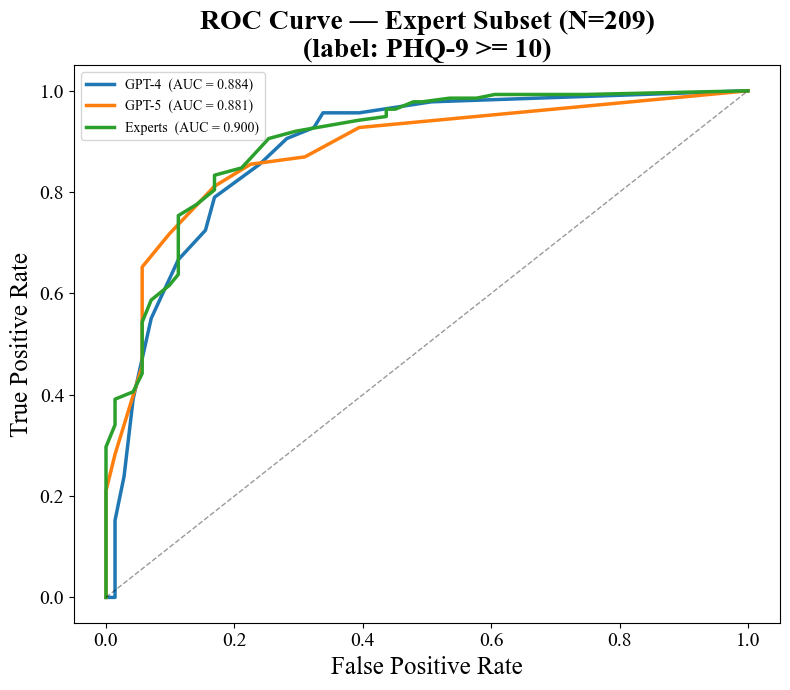


Pairwise AUC significance (bootstrap, 1000 trials):
  Comparison                    ΔAUC        p   sig
  GPT-4 vs GPT-5              +0.003    0.902    ns
  GPT-4 vs Experts            -0.016    0.424    ns
  GPT-5 vs Experts            -0.019    0.210    ns


In [17]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from matplotlib import font_manager as _fm

_font_path      = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
_bold_font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf'
_font      = _fm.FontProperties(fname=_font_path)
_font_bold = _fm.FontProperties(fname=_bold_font_path)

# ============================================================
# CONSTRUCT-LEVEL ROC: expert-annotated subset
# Label: self-report PHQ-9 total >= 10 (Kroenke et al. 2001)
# Models: GPT-4, GPT-5, averaged experts
# ============================================================

# Average expert scores
_exp_merged = pd.merge(
    expert1_df[['user_id'] + score_columns],
    expert2_df[['user_id'] + score_columns],
    on='user_id', suffixes=('_e1', '_e2')
)
_expert_avg = pd.DataFrame({'user_id': _exp_merged['user_id']})
for _col in score_columns:
    _expert_avg[_col] = (_exp_merged[f'{_col}_e1'] + _exp_merged[f'{_col}_e2']) / 2.0

# Restrict to expert-annotated subset
_expert_ids = set(expert1_df['user_id']) & set(expert2_df['user_id'])
_sr_sub   = self_report_df[self_report_df.user_id.isin(_expert_ids)].set_index('user_id')
_gpt4_sub = gpt4_df[gpt4_df.user_id.isin(_expert_ids)].set_index('user_id')
_gpt5_sub = gpt5_df[gpt5_df.user_id.isin(_expert_ids)].set_index('user_id')
_exp_sub  = _expert_avg.set_index('user_id')

_common = (_sr_sub.index.intersection(_gpt4_sub.index)
           .intersection(_gpt5_sub.index).intersection(_exp_sub.index))
_sr_sub, _gpt4_sub, _gpt5_sub, _exp_sub = [
    df.loc[_common] for df in [_sr_sub, _gpt4_sub, _gpt5_sub, _exp_sub]]
print(f'Expert-annotated subset N: {len(_common)}')

_sr_total   = _sr_sub[score_columns].sum(axis=1)
_gpt4_total = _gpt4_sub[score_columns].sum(axis=1)
_gpt5_total = _gpt5_sub[score_columns].sum(axis=1)
_exp_total  = _exp_sub[score_columns].sum(axis=1)

_y_label = (_sr_total >= 10).astype(int)
print(f'Prevalence (PHQ-9 >= 10): {_y_label.mean():.1%}  ({_y_label.sum()}/{len(_y_label)})')

# Bootstrap p-value for AUC difference (H0: AUC_A == AUC_B, two-tailed)
def _auc_pval(y_true, scores_a, scores_b, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        if len(np.unique(yt)) < 2:
            continue
        diffs.append(roc_auc_score(yt, scores_a[idx]) - roc_auc_score(yt, scores_b[idx]))
    diffs = np.array(diffs)
    return 2.0 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))

_scores_sub = {
    'GPT-4':   _gpt4_total.values,
    'GPT-5':   _gpt5_total.values,
    'Experts': _exp_total.values,
}
_colors = {'GPT-4': '#1f77b4', 'GPT-5': '#ff7f0e', 'Experts': '#2ca02c'}

fig, ax = plt.subplots(figsize=(8, 7))
for _name, _sc in _scores_sub.items():
    _fpr, _tpr, _ = roc_curve(_y_label.values, _sc)
    ax.plot(_fpr, _tpr, color=_colors[_name], lw=2.5,
            label=f'{_name}  (AUC = {auc(_fpr, _tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=18, fontproperties=_font)
ax.set_ylabel('True Positive Rate', fontsize=18, fontproperties=_font)
ax.set_title('ROC Curve — Expert Subset (N=' + str(len(_common)) + ')\n(label: PHQ-9 >= 10)', fontsize=20, fontproperties=_font_bold)
ax.legend(prop=_font, fontsize=14)
for _t in ax.get_xticklabels() + ax.get_yticklabels():
    _t.set_fontproperties(_font); _t.set_fontsize(14)
plt.tight_layout()
plt.savefig('../data/figures/construct_roc_expert_subset.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Pairwise AUC significance (bootstrap, 1000 trials)
print('\nPairwise AUC significance (bootstrap, 1000 trials):')
print(f"  {'Comparison':<25} {'ΔAUC':>8} {'p':>8} {'sig':>5}")
for _a, _b in [('GPT-4','GPT-5'), ('GPT-4','Experts'), ('GPT-5','Experts')]:
    _da = roc_auc_score(_y_label.values, _scores_sub[_a]) - roc_auc_score(_y_label.values, _scores_sub[_b])
    _p  = _auc_pval(_y_label.values, _scores_sub[_a], _scores_sub[_b])
    _s  = '***' if _p<0.001 else '**' if _p<0.01 else '*' if _p<0.05 else 'ns'
    print(f"  {_a+' vs '+_b:<25} {_da:>+8.3f} {_p:>8.3f} {_s:>5}")


Full dataset N: 955
Prevalence (PHQ-9 >= 10): 56.4%  (539/955)


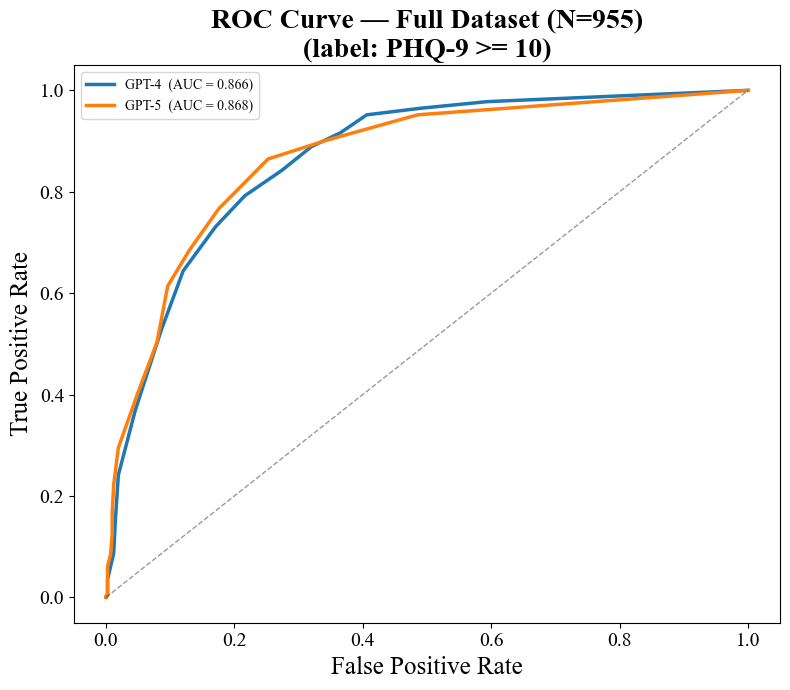


GPT-4 vs GPT-5 (full dataset):  ΔAUC = -0.002,  p = 0.798  ns


In [18]:
# ============================================================
# CONSTRUCT-LEVEL ROC: full dataset
# GPT-4 vs GPT-5 only (no expert labels available for full set)
# Label: self-report PHQ-9 total >= 10
# Requires: _font, _font_bold, _auc_pval from cell above
# ============================================================

_sr_f   = self_report_df.set_index('user_id')
_gpt4_f = gpt4_df.set_index('user_id')
_gpt5_f = gpt5_df.set_index('user_id')

_ids_f = _sr_f.index.intersection(_gpt4_f.index).intersection(_gpt5_f.index)
_sr_f, _gpt4_f, _gpt5_f = [df.loc[_ids_f] for df in [_sr_f, _gpt4_f, _gpt5_f]]
print(f'Full dataset N: {len(_ids_f)}')

_y_full = (_sr_f[score_columns].sum(axis=1) >= 10).astype(int)
print(f'Prevalence (PHQ-9 >= 10): {_y_full.mean():.1%}  ({_y_full.sum()}/{len(_y_full)})')

_scores_full = {
    'GPT-4': _gpt4_f[score_columns].sum(axis=1).values,
    'GPT-5': _gpt5_f[score_columns].sum(axis=1).values,
}

fig2, ax2 = plt.subplots(figsize=(8, 7))
for _name, _sc in _scores_full.items():
    _fpr, _tpr, _ = roc_curve(_y_full.values, _sc)
    ax2.plot(_fpr, _tpr, color=_colors[_name], lw=2.5,
             label=f'{_name}  (AUC = {auc(_fpr, _tpr):.3f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax2.set_xlabel('False Positive Rate', fontsize=18, fontproperties=_font)
ax2.set_ylabel('True Positive Rate', fontsize=18, fontproperties=_font)
ax2.set_title('ROC Curve — Full Dataset (N=' + str(len(_ids_f)) + ')\n(label: PHQ-9 >= 10)', fontsize=20, fontproperties=_font_bold)
ax2.legend(prop=_font, fontsize=14)
for _t in ax2.get_xticklabels() + ax2.get_yticklabels():
    _t.set_fontproperties(_font); _t.set_fontsize(14)
plt.tight_layout()
plt.savefig('../data/figures/construct_roc_full.pdf', dpi=300, bbox_inches='tight')
plt.show()

_da_f = roc_auc_score(_y_full.values, _scores_full['GPT-4']) - roc_auc_score(_y_full.values, _scores_full['GPT-5'])
_p_f  = _auc_pval(_y_full.values, _scores_full['GPT-4'], _scores_full['GPT-5'])
_s_f  = '***' if _p_f<0.001 else '**' if _p_f<0.01 else '*' if _p_f<0.05 else 'ns'
print(f'\nGPT-4 vs GPT-5 (full dataset):  ΔAUC = {_da_f:+.3f},  p = {_p_f:.3f}  {_s_f}')


In [19]:
# ============================================================
# SYMPTOM-LEVEL BINARY CLASSIFICATION TABLES
# Binary label: score > 0 (symptom present) vs 0 (absent)
# N = expert-annotated subset (consistent with Table 2)
# Requires: _sr_sub, _gpt4_sub, _gpt5_sub, _exp_sub from ROC cell
# ============================================================

_sym_short = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite',
              'Worth/Guilt', 'Concentration', 'Psychomotor', 'Suicidal']

def _metrics(y_true, y_pred):
    tp = int(np.sum((y_true==1)&(y_pred==1)))
    tn = int(np.sum((y_true==0)&(y_pred==0)))
    fp = int(np.sum((y_true==0)&(y_pred==1)))
    fn = int(np.sum((y_true==1)&(y_pred==0)))
    sens  = tp/(tp+fn)    if (tp+fn)>0    else np.nan
    spec  = tn/(tn+fp)    if (tn+fp)>0    else np.nan
    prec  = tp/(tp+fp)    if (tp+fp)>0    else np.nan
    f1p   = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else np.nan  # F1 for class 1
    f1n   = 2*tn/(2*tn+fn+fp) if (2*tn+fn+fp)>0 else np.nan  # F1 for class 0
    macro = (f1p+f1n)/2   if not (np.isnan(f1p) or np.isnan(f1n)) else np.nan
    return {'Sensitivity': sens, 'Specificity': spec, 'Precision': prec, 'Macro-F1': macro}

_cols  = ['Sensitivity', 'Specificity', 'Precision', 'Macro-F1']

# TABLE 1: self-report as gold label
_t1_models  = ['GPT-4', 'GPT-5', 'Experts']
_t1_pred_df = {'GPT-4': _gpt4_sub, 'GPT-5': _gpt5_sub, 'Experts': _exp_sub}
_t1_rows = []
for _col, _sym in zip(score_columns, _sym_short):
    _gold = (_sr_sub[_col].values > 0).astype(int)
    _row  = {'Symptom': _sym}
    for _mn, _df in _t1_pred_df.items():
        _m = _metrics(_gold, (_df[_col].values > 0).astype(int))
        for _c in _cols:
            _row[f'{_mn}_{_c}'] = _m[_c]
    _t1_rows.append(_row)
_t1 = pd.DataFrame(_t1_rows).set_index('Symptom')

# TABLE 2: averaged expert as gold label (GPT-4, GPT-5 only)
_t2_models  = ['GPT-4', 'GPT-5']
_t2_pred_df = {'GPT-4': _gpt4_sub, 'GPT-5': _gpt5_sub}
_t2_rows = []
for _col, _sym in zip(score_columns, _sym_short):
    _gold = (_exp_sub[_col].values > 0).astype(int)
    _row  = {'Symptom': _sym}
    for _mn, _df in _t2_pred_df.items():
        _m = _metrics(_gold, (_df[_col].values > 0).astype(int))
        for _c in _cols:
            _row[f'{_mn}_{_c}'] = _m[_c]
    _t2_rows.append(_row)
_t2 = pd.DataFrame(_t2_rows).set_index('Symptom')

# Pretty-print both tables
for _tname, _tdf, _mnames in [
        ('Table 1 (gold: self-report > 0)', _t1, _t1_models),
        ('Table 2 (gold: expert avg > 0)',   _t2, _t2_models)]:
    print(f'\n{_tname}')
    print(f"  {'Symptom':<18}", end='')
    for _mn in _mnames:
        for _c in ['Sens', 'Spec', 'Prec', 'MF1']:
            print(f'  {_mn[:4]}-{_c}', end='')
    print()
    for _sym in _sym_short:
        print(f'  {_sym:<18}', end='')
        for _mn in _mnames:
            for _c, _ck in zip(['Sens','Spec','Prec','MF1'],
                               ['Sensitivity','Specificity','Precision','Macro-F1']):
                _v = _tdf.loc[_sym, f'{_mn}_{_ck}']
                print(f'  {"nan" if np.isnan(_v) else f"{_v:.2f}":>8}', end='')
        print()



Table 1 (gold: self-report > 0)
  Symptom             GPT--Sens  GPT--Spec  GPT--Prec  GPT--MF1  GPT--Sens  GPT--Spec  GPT--Prec  GPT--MF1  Expe-Sens  Expe-Spec  Expe-Prec  Expe-MF1
  Anhedonia               0.84      0.81      0.95      0.76      0.78      0.92      0.98      0.74      0.88      0.81      0.96      0.80
  Depressed               0.91      0.80      0.95      0.83      0.86      0.85      0.96      0.80      0.93      0.72      0.93      0.82
  Sleep                   0.80      0.71      0.91      0.72      0.50      0.98      0.99      0.59      0.92      0.56      0.88      0.75
  Fatigue                 0.83      0.96      0.99      0.75      0.53      1.00      1.00      0.53      0.91      0.76      0.97      0.79
  Appetite                0.59      0.84      0.91      0.64      0.16      0.98      0.96      0.37      0.93      0.54      0.85      0.75
  Worth/Guilt             0.73      0.89      0.96      0.72      0.37      1.00      1.00      0.50      0.88  

In [22]:
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

# ============================================================
# LATEX TABLE OUTPUT WITH CELL COLOR CODING
# Color scale: RdYlGn (0 = red, 0.5 = yellow, 1 = green)
# Requires _t1, _t2, _cols, _sym_short, _t1_models, _t2_models
# ============================================================

def _hex(v, vmin=0.0, vmax=1.0):
    if np.isnan(v):
        return 'FFFFFF'
    norm = max(0.0, min(1.0, (v - vmin) / (vmax - vmin)))
    r, g, b, _ = _cm.RdYlGn(norm)
    return f'{int(r*255):02X}{int(g*255):02X}{int(b*255):02X}'

def _latex_table(tdf, model_names, caption, label):
    n_models = len(model_names)
    col_spec  = 'l' + ('|cccc' * n_models)
    lines = []
    lines.append(r'\begin{table}[h]')
    lines.append(r'\centering')
    lines.append(r'\footnotesize')
    lines.append(r'\setlength{\tabcolsep}{4pt}')
    lines.append(f'\\begin{{tabular}}{{{col_spec}}}')
    lines.append(r'\toprule')
    # header row 1: model group spans
    hdr1 = ''
    for _i, _mn in enumerate(model_names):
        sep = '|' if _i < n_models - 1 else ''
        hdr1 += f' & \\multicolumn{{4}}{{c{sep}}}{{{_mn}}}'
    lines.append('Symptom' + hdr1 + r' \\')
    lines.append(r'\cmidrule(lr){2-5}' if n_models == 2
                 else r'\cmidrule(lr){2-5}\cmidrule(lr){6-9}\cmidrule(lr){10-13}')
    # header row 2: metric names
    hdr2 = ('& Sens & Spec & Prec & Macro-F1 ' * n_models)
    lines.append('& ' + hdr2.strip(' &') + r' \\')
    lines.append(r'\midrule')
    # data rows
    for _sym in _sym_short:
        row_cells = [_sym.replace('/', '/')]
        for _mn in model_names:
            for _c in ['Sensitivity', 'Specificity', 'Precision', 'Macro-F1']:
                _v = tdf.loc[_sym, f'{_mn}_{_c}']
                _color = _hex(_v)
                _vstr  = 'N/A' if np.isnan(_v) else f'{_v:.2f}'
                row_cells.append(f'\\cellcolor[HTML]{{{_color}}}{_vstr}')
        lines.append(' & '.join(row_cells) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(f'\\caption{{{caption}}}')
    lines.append(f'\\label{{{label}}}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

_latex1 = _latex_table(
    _t1, _t1_models,
    caption='Symptom-level binary classification metrics. Gold label: self-report score > 0 (symptom present). N = expert-annotated subset.',
    label='tab:symptom_sr'
)
_latex2 = _latex_table(
    _t2, _t2_models,
    caption='Symptom-level binary classification metrics. Gold label: averaged expert score > 0. N = expert-annotated subset.',
    label='tab:symptom_expert'
)

print('% ---- TABLE 1 (gold: self-report) ----')
print(_latex1)
print()
print('% ---- TABLE 2 (gold: expert avg) ----')
print(_latex2)


% ---- TABLE 1 (gold: self-report) ----
\begin{table}[h]
\centering
\footnotesize
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l|cccc|cccc|cccc}
\toprule
Symptom & \multicolumn{4}{c|}{GPT-4} & \multicolumn{4}{c|}{GPT-5} & \multicolumn{4}{c}{Experts} \\
\cmidrule(lr){2-5}\cmidrule(lr){6-9}\cmidrule(lr){10-13}
& Sens & Spec & Prec & Macro-F1 & Sens & Spec & Prec & Macro-F1 & Sens & Spec & Prec & Macro-F1 \\
\midrule
Anhedonia & \cellcolor[HTML]{48AE5B}0.84 & \cellcolor[HTML]{60BA61}0.81 & \cellcolor[HTML]{0B7C41}0.95 & \cellcolor[HTML]{7FC765}0.76 & \cellcolor[HTML]{72C264}0.78 & \cellcolor[HTML]{158F4B}0.92 & \cellcolor[HTML]{05713B}0.98 & \cellcolor[HTML]{89CC66}0.74 & \cellcolor[HTML]{2A9F54}0.88 & \cellcolor[HTML]{60BA61}0.81 & \cellcolor[HTML]{0B7C41}0.96 & \cellcolor[HTML]{68BE63}0.80 \\
Depressed & \cellcolor[HTML]{16914C}0.91 & \cellcolor[HTML]{66BD63}0.80 & \cellcolor[HTML]{0C7E42}0.95 & \cellcolor[HTML]{4BAF5C}0.83 & \cellcolor[HTML]{39A757}0.86 & \cellcolor[HTML]{3FAA59}0.85 & 

## Distribution

In [18]:
from matplotlib import font_manager
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
bold_font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf'
italics_font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf'
# Create a font properties object
custom_font = font_manager.FontProperties(fname=font_path)
custom_font_bold = font_manager.FontProperties(fname=bold_font_path)
custom_font_italics = font_manager.FontProperties(fname=italics_font_path)

In [19]:
from matplotlib.colorbar import ColorbarBase
from matplotlib import gridspec
import matplotlib.colors

Text(0.5, 1.0, 'Average\n')

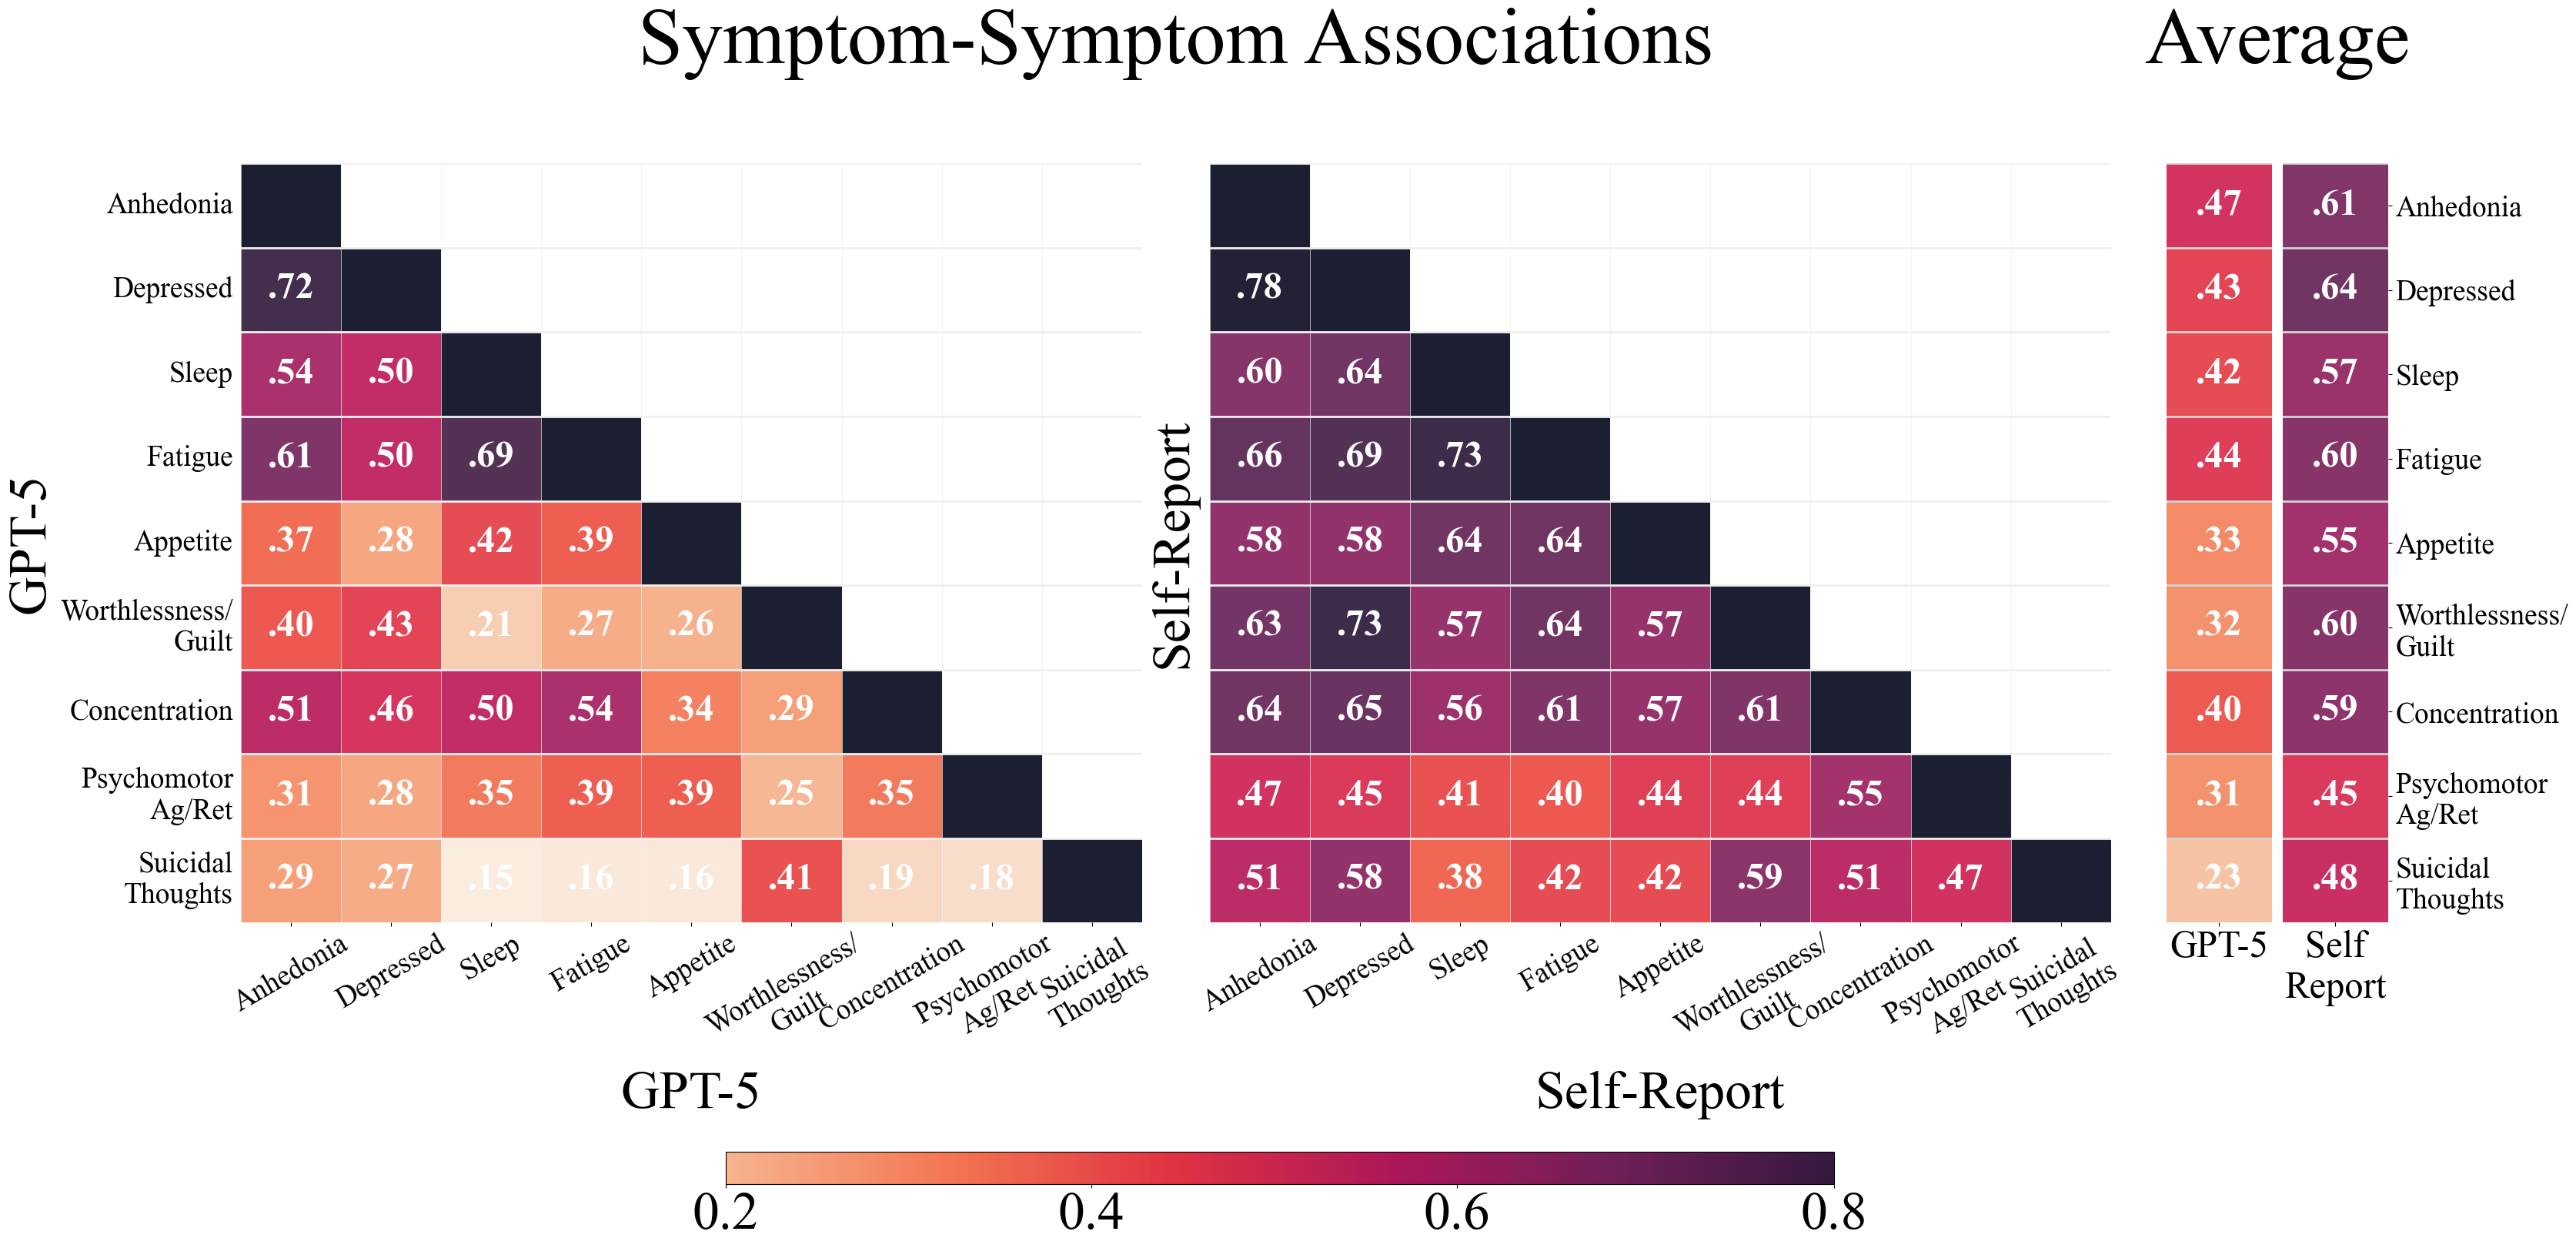

In [20]:
# Make gridspec such that there are two parts to the figure, 
# one which will be split into subplots for correlation matrix 
# and the other will be for the average
# The former will have more wspace between the heatmaps and the latter will have less wspace

f = plt.figure(figsize=(36, 17))
gs1 = gridspec.GridSpec(1, 2, figure=f, right=0.80, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.075)
gs2 = gridspec.GridSpec(1, 2, figure=f, left=0.82, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.1)
gs3 = gridspec.GridSpec(1, 1, figure=f, top=0.125, bottom=0.1, left=0.3, right=0.7, hspace=0.1)

# put gpt4 corr map in a0 and self report corr map in a1
# put gpt4 avg in a2 and self report avg in a3
a0 = f.add_subplot(gs1[0])
a1 = f.add_subplot(gs1[1])
a2 = f.add_subplot(gs2[0])
a3 = f.add_subplot(gs2[1])
a4 = f.add_subplot(gs3[0])

# Correlation in between all the items 
corr_df = gpt5_df[[i for i in score_columns]].corr().values.round(2)
corr_df_annot = gpt5_df[[i for i in score_columns]].corr().apply(lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_annot.iloc[i, i] = ''
# Turn this into sns heatmap, with x axis label rotated 35 degrees, font size of the correlation values inside the heatmap as 20

# corrs_trials = []
# for trial in range(10):
#     # sample shape[0] users with replacement
#     sample = gpt4_df.sample(n=gpt4_df.shape[0], replace=True)
#     # calculate the correlation matrix
#     corr_df = sample[[i for i in score_columns]].corr().values.round(2)
#     # append to corrs_trials
#     corrs_trials.append(corr_df)

# # create a 3D array of the correlation matrices
# corrs_trials = np.array(corrs_trials)
# # sort along the trials axis and take the 2.5th and 97.5th percentiles
# lower_bound = np.percentile(corrs_trials, 2.5, axis=0)
# upper_bound = np.percentile(corrs_trials, 97.5, axis=0)

# # annotate the corr_df_annot with [lower_bound, upper_bound] below the correlation values in smaller font
# conf_bounds_annot = corr_df_annot.copy()
# for idx in range(9):
#     for jdx in range(9):
#         if idx != jdx:
#             conf_bounds_annot.iloc[idx, jdx] = '['+f'{lower_bound[idx, jdx]:.2f}'[-3:]+','+ f'{upper_bound[idx, jdx]:.2f}]'[-4:]

mask = np.zeros_like(corr_df, dtype="bool")
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False

# f, (a0, a1, a2, a3) = plt.subplots(1, 4, figsize=(36, 15), gridspec_kw={'width_ratios': [3, 3, 0.35, 0.35], 'wspace': 0.1})

sns.heatmap(corr_df, annot = corr_df_annot, mask=mask, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'}, 
            ax=a0, cbar=False)

# # Add custom annotations
# for i in range(corr_df.shape[0]):
#     for j in range(corr_df.shape[1]):
#         if not mask[i, j]:
#             corr_text = corr_df_annot.iloc[i, j]
#             conf_bounds = conf_bounds_annot.iloc[i, j]
            
#             a0.text(j + 0.5, i + 0.5, corr_text, ha='center', va='center',
#                     fontsize=30, fontweight='bold', color='white', fontproperties=custom_font_bold)
#             a0.text(j + 0.5, i + 0.75, conf_bounds, ha='center', va='center',
#                     fontsize=18, color='white', fontproperties=custom_font)


a0.tick_params(left=False, bottom=True)

for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)


tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']

a0.set_xticklabels(tick_labels, rotation=30, fontsize=27, fontproperties=custom_font)
a0.set_yticklabels(tick_labels_y, rotation=0, fontsize=27,  fontproperties=custom_font)
a0.set_xlabel('GPT-5', fontsize=50, fontproperties=custom_font)
a0.set_ylabel('GPT-5', fontsize=50, fontproperties=custom_font)

avgs = ((corr_df.sum(axis=1)-1.0)/8).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:]] for row in avgs for v in row]
sns.heatmap(avgs, annot=avgs_annot, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='', ax=a2, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=False)

for i in range(9):
    a2.axhline(i, color='lightgray', lw=2)

a2.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a2.yaxis.tick_right()
a2.tick_params(right=False, bottom=True, left=False)
a2.set_xticklabels(['GPT-5'], rotation=0, fontsize=35,  fontproperties=custom_font)

###########################
###########################

# Correlation in between all the items 
corr_df = self_report_df[[i for i in score_columns]].corr().values.round(2)
corr_df_annot = self_report_df[[i for i in score_columns]].corr().apply(lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_annot.iloc[i, i] = ''

sns.heatmap(corr_df, annot = corr_df_annot, mask=mask, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'}, 
            ax=a1, cbar=False)

a1.tick_params(left=False, bottom=True)

for i in range(9):
    a1.axhline(i, color='#f0f0f0', lw=2)
    a1.axvline(i, color='#f0f0f0', lw=.5)
# a0.axhline(7, color='white', lw=6)
# a0.axhline(7, color='#f0f0f0', lw=2)

tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']

a1.set_xticklabels(tick_labels, rotation=30, fontsize=27, fontproperties=custom_font)
a1.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a1.set_xlabel('Self-Report', fontsize=50, fontproperties=custom_font)
a1.set_ylabel('Self-Report', fontsize=50, fontproperties=custom_font)

avgs = ((corr_df.sum(axis=1)-1.0)/8).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:]] for row in avgs for v in row]
sns.heatmap(avgs, annot=avgs_annot, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='', ax=a3, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=False)

for i in range(9):
    a3.axhline(i, color='lightgray', lw=2)

a3.set_yticklabels(tick_labels_y, rotation=0, fontsize=27,  fontproperties=custom_font)
a3.yaxis.tick_right()
a3.tick_params(right=True, bottom=True, left=False)
a3.set_xticklabels(['Self\nReport'], rotation=0, fontsize=35,  fontproperties=custom_font)

###########################
###########################

rocket_r_colors = sns.color_palette("rocket_r").as_hex()
my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", rocket_r_colors)

# Add colorbar to a4
cb1 = ColorbarBase(a4, cmap=my_cmap, orientation='horizontal', alpha=0.9)
# set 4 x ticks
cb1.set_ticks([0.0, 0.33, 0.66, 1.0])
a4.set_xticklabels([0.2, 0.4, 0.6, 0.8], fontsize=50, fontproperties=custom_font)

###########################
###########################

# Add ghost axes and titles on gs1 and gs2
ax_left = f.add_subplot(gs1[:])
ax_left.axis('off')
ax_left.set_title('Symptom-Symptom Associations\n', fontsize=75, fontproperties=custom_font)

ax_right = f.add_subplot(gs2[:])
ax_right.axis('off')
ax_right.set_title('Average\n', fontsize=75, fontproperties=custom_font)

# plt.savefig('../data/figures/InterSymptomrelationship2GPT5.pdf', dpi=1040, bbox_inches='tight', format='pdf')

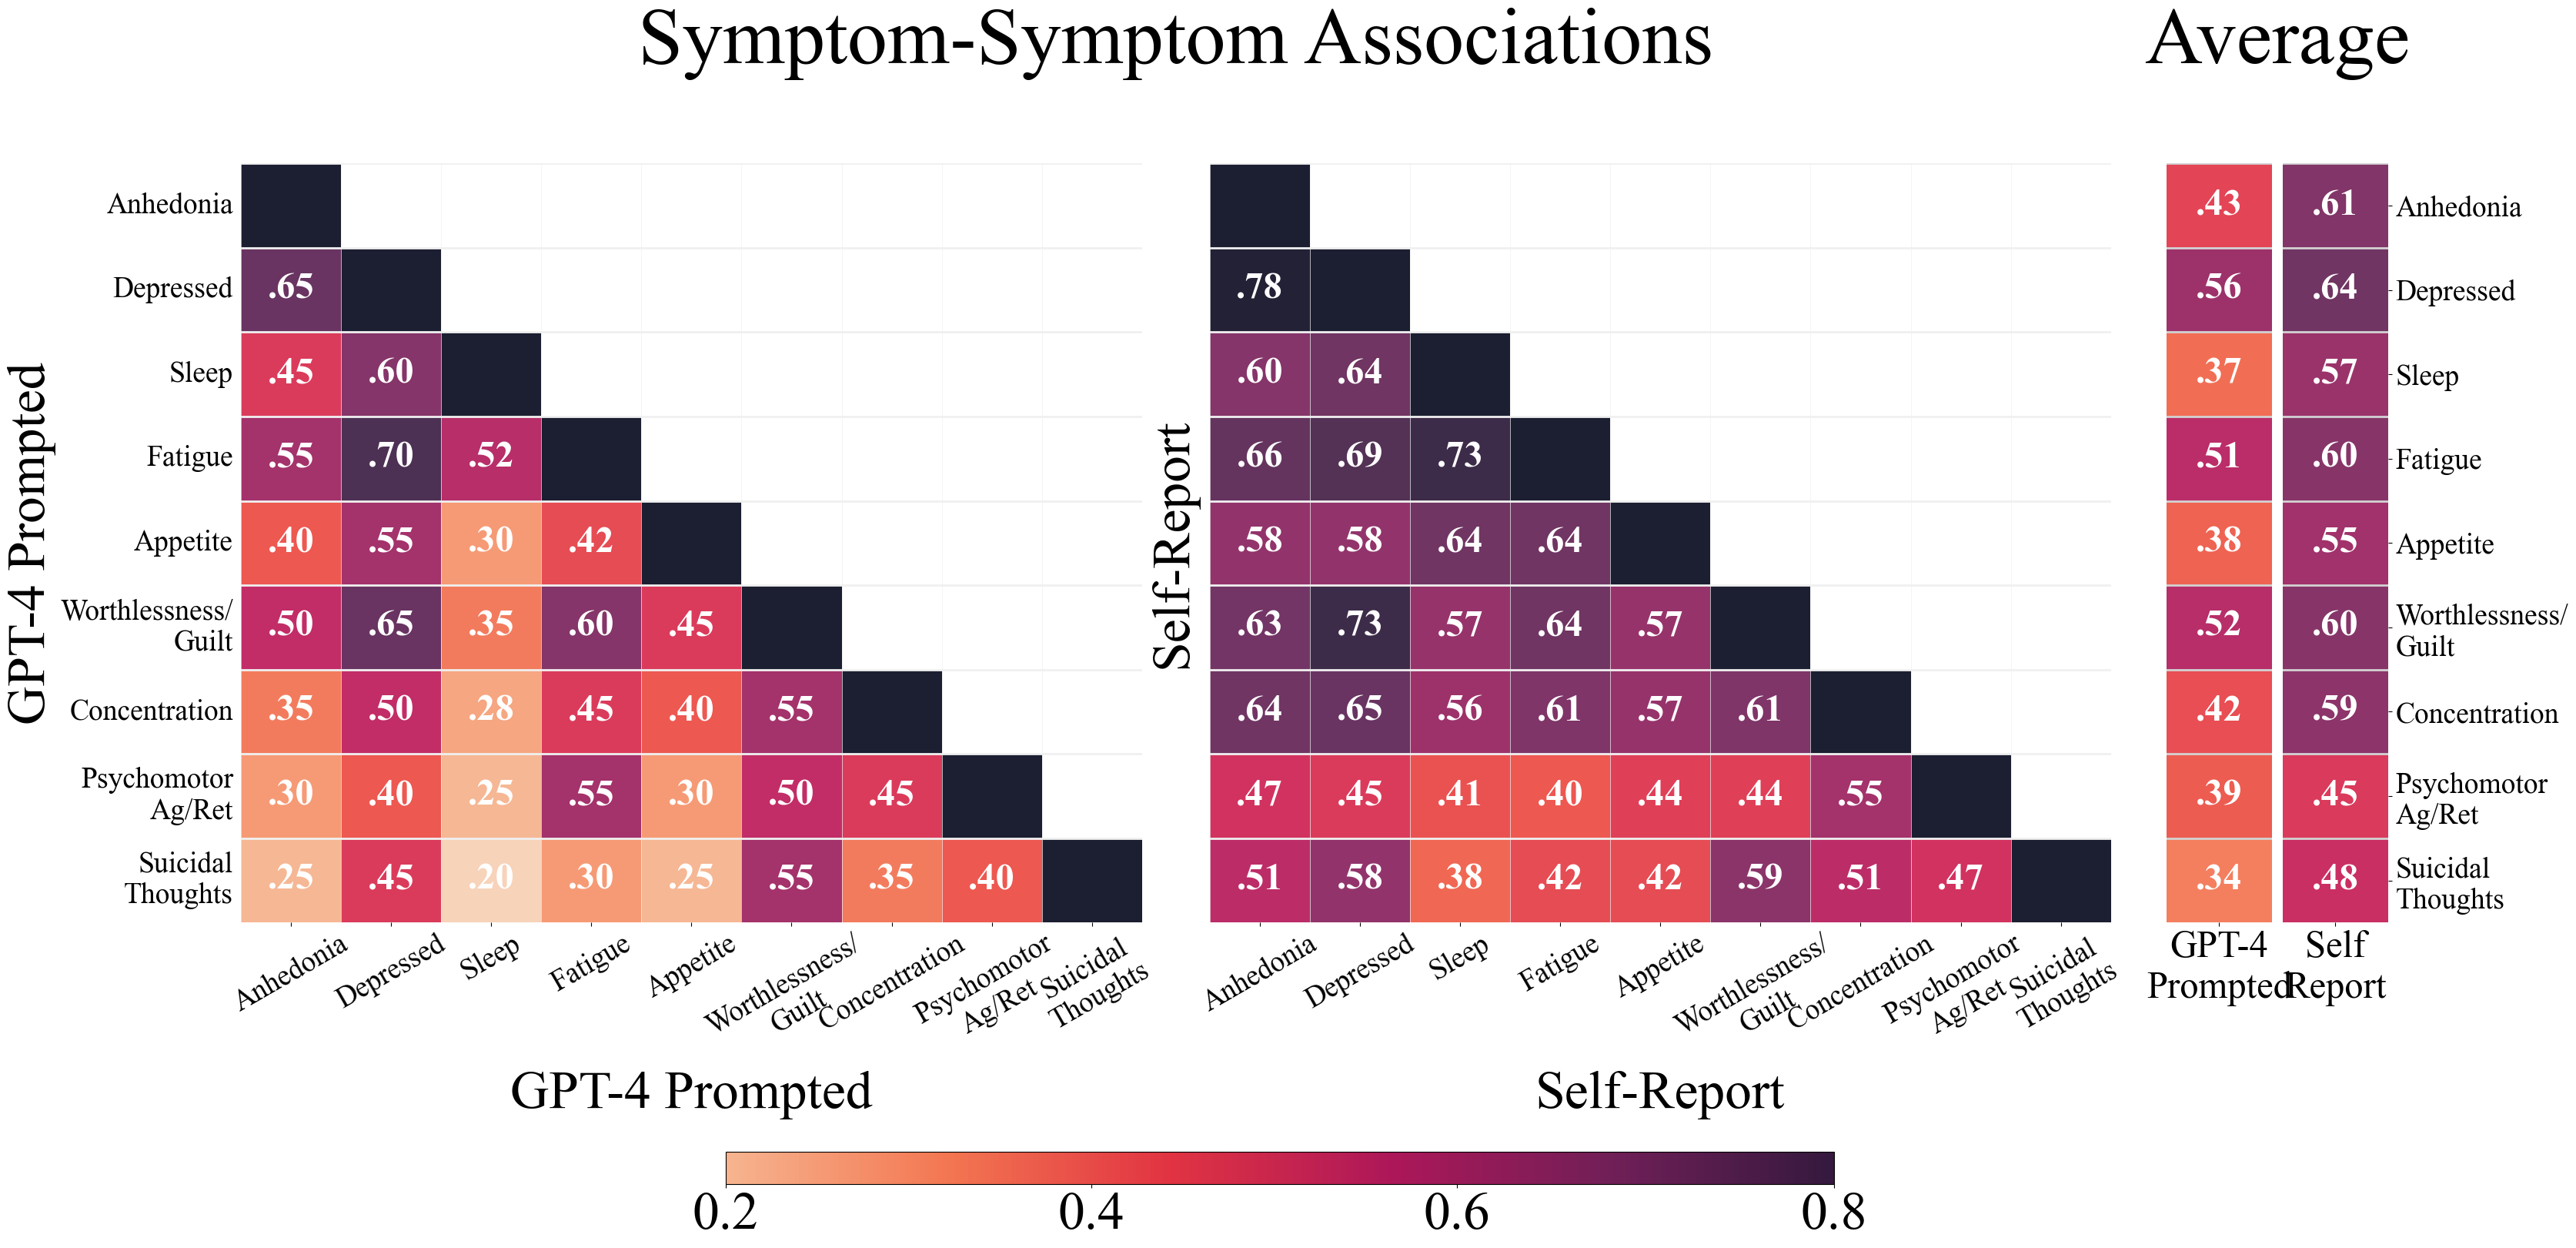

In [21]:
# GPT-4 Prompted (hypothesized) lower-triangle correlation matrix
# Rows/cols: 1=Anhedonia, 2=Depressed, 3=Sleep, 4=Fatigue,
#            5=Appetite, 6=Worthlessness/Guilt, 7=Concentration,
#            8=PsychomotorAg/Ret, 9=Suicidal Thoughts
gpt4_prompted_vals = np.array([
    [1.00, 0.65, 0.45, 0.55, 0.40, 0.50, 0.35, 0.30, 0.25],
    [0.65, 1.00, 0.60, 0.70, 0.55, 0.65, 0.50, 0.40, 0.45],
    [0.45, 0.60, 1.00, 0.52, 0.30, 0.35, 0.28, 0.25, 0.20],
    [0.55, 0.70, 0.52, 1.00, 0.42, 0.60, 0.45, 0.55, 0.30],
    [0.40, 0.55, 0.30, 0.42, 1.00, 0.45, 0.40, 0.30, 0.25],
    [0.50, 0.65, 0.35, 0.60, 0.45, 1.00, 0.55, 0.50, 0.55],
    [0.35, 0.50, 0.28, 0.45, 0.40, 0.55, 1.00, 0.45, 0.35],
    [0.30, 0.40, 0.25, 0.55, 0.30, 0.50, 0.45, 1.00, 0.40],
    [0.25, 0.45, 0.20, 0.30, 0.25, 0.55, 0.35, 0.40, 1.00],
])

gpt4_prompted_annot = [[f'{v:.2f}'[-3:] if i != j else '' for j, v in enumerate(row)]
                        for i, row in enumerate(gpt4_prompted_vals)]

# Self-report correlation matrix (same as cell above)
corr_df_sr = self_report_df[[i for i in score_columns]].corr().values.round(2)
corr_df_sr_annot = self_report_df[[i for i in score_columns]].corr().apply(
    lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_sr_annot.iloc[i, i] = ''

mask = np.zeros((9, 9), dtype="bool")
mask[np.triu_indices(9)] = True
mask[np.diag_indices(9)] = False

tick_labels   = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite',
                 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']
tick_labels_y = tick_labels

f = plt.figure(figsize=(36, 17))
gs1 = gridspec.GridSpec(1, 2, figure=f, right=0.80, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.075)
gs2 = gridspec.GridSpec(1, 2, figure=f, left=0.82, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.1)
gs3 = gridspec.GridSpec(1, 1, figure=f, top=0.125, bottom=0.1, left=0.3, right=0.7, hspace=0.1)

a0 = f.add_subplot(gs1[0])   # GPT-4 Prompted heatmap
a1 = f.add_subplot(gs1[1])   # Self-Report heatmap
a2 = f.add_subplot(gs2[0])   # GPT-4 Prompted avg
a3 = f.add_subplot(gs2[1])   # Self-Report avg
a4 = f.add_subplot(gs3[0])   # Colorbar

# -- GPT-4 Prompted ----------------------------------------------------------
sns.heatmap(gpt4_prompted_vals, annot=gpt4_prompted_annot, mask=mask,
            cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='',
            annot_kws={'fontsize': 35, 'fontweight': 'bold',
                       'fontproperties': custom_font_bold, 'color': 'white'},
            ax=a0, cbar=False)

a0.tick_params(left=False, bottom=True)
for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)

a0.set_xticklabels(tick_labels,   rotation=30, fontsize=27, fontproperties=custom_font)
a0.set_yticklabels(tick_labels_y, rotation=0,  fontsize=27, fontproperties=custom_font)
a0.set_xlabel('GPT-4 Prompted', fontsize=50, fontproperties=custom_font)
a0.set_ylabel('GPT-4 Prompted', fontsize=50, fontproperties=custom_font)

avgs_gpt4 = ((gpt4_prompted_vals.sum(axis=1) - 1.0) / 8).reshape(-1, 1)
avgs_gpt4_annot = [[f'{v:.2f}'[-3:]] for row in avgs_gpt4 for v in row]
sns.heatmap(avgs_gpt4, annot=avgs_gpt4_annot, cmap='rocket_r', vmin=0.15, vmax=0.8,
            alpha=0.9, fmt='', ax=a2,
            annot_kws={'fontsize': 35, 'fontweight': 'bold',
                       'fontproperties': custom_font_bold, 'color': 'white'},
            cbar=False)
for i in range(9): a2.axhline(i, color='lightgray', lw=2)
a2.set_yticklabels([], rotation=0, fontsize=27, fontproperties=custom_font)
a2.yaxis.tick_right()
a2.tick_params(right=False, bottom=True, left=False)
a2.set_xticklabels(['GPT-4\nPrompted'], rotation=0, fontsize=35, fontproperties=custom_font)

# -- Self-Report -------------------------------------------------------------
sns.heatmap(corr_df_sr, annot=corr_df_sr_annot, mask=mask,
            cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='',
            annot_kws={'fontsize': 35, 'fontweight': 'bold',
                       'fontproperties': custom_font_bold, 'color': 'white'},
            ax=a1, cbar=False)

a1.tick_params(left=False, bottom=True)
for i in range(9):
    a1.axhline(i, color='#f0f0f0', lw=2)
    a1.axvline(i, color='#f0f0f0', lw=.5)

a1.set_xticklabels(tick_labels, rotation=30, fontsize=27, fontproperties=custom_font)
a1.set_yticklabels([], rotation=0, fontsize=27, fontproperties=custom_font)
a1.set_xlabel('Self-Report', fontsize=50, fontproperties=custom_font)
a1.set_ylabel('Self-Report', fontsize=50, fontproperties=custom_font)

avgs_sr = ((corr_df_sr.sum(axis=1) - 1.0) / 8).reshape(-1, 1)
avgs_sr_annot = [[f'{v:.2f}'[-3:]] for row in avgs_sr for v in row]
sns.heatmap(avgs_sr, annot=avgs_sr_annot, cmap='rocket_r', vmin=0.15, vmax=0.8,
            alpha=0.9, fmt='', ax=a3,
            annot_kws={'fontsize': 35, 'fontweight': 'bold',
                       'fontproperties': custom_font_bold, 'color': 'white'},
            cbar=False)
for i in range(9): a3.axhline(i, color='lightgray', lw=2)
a3.set_yticklabels(tick_labels_y, rotation=0, fontsize=27, fontproperties=custom_font)
a3.yaxis.tick_right()
a3.tick_params(right=True, bottom=True, left=False)
a3.set_xticklabels(['Self\nReport'], rotation=0, fontsize=35, fontproperties=custom_font)

# -- Shared colorbar ---------------------------------------------------------
rocket_r_colors = sns.color_palette("rocket_r").as_hex()
my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", rocket_r_colors)
cb1 = ColorbarBase(a4, cmap=my_cmap, orientation='horizontal', alpha=0.9)
cb1.set_ticks([0.0, 0.33, 0.66, 1.0])
a4.set_xticklabels([0.2, 0.4, 0.6, 0.8], fontsize=50, fontproperties=custom_font)

# -- Titles ------------------------------------------------------------------
ax_left = f.add_subplot(gs1[:])
ax_left.axis('off')
ax_left.set_title('Symptom-Symptom Associations\n', fontsize=75, fontproperties=custom_font)

ax_right = f.add_subplot(gs2[:])
ax_right.axis('off')
ax_right.set_title('Average\n', fontsize=75, fontproperties=custom_font)

# plt.savefig('../data/figures/InterSymptomRelationship_GPT4Prompted_SR.pdf', dpi=1040, bbox_inches='tight', format='pdf')
plt.show()


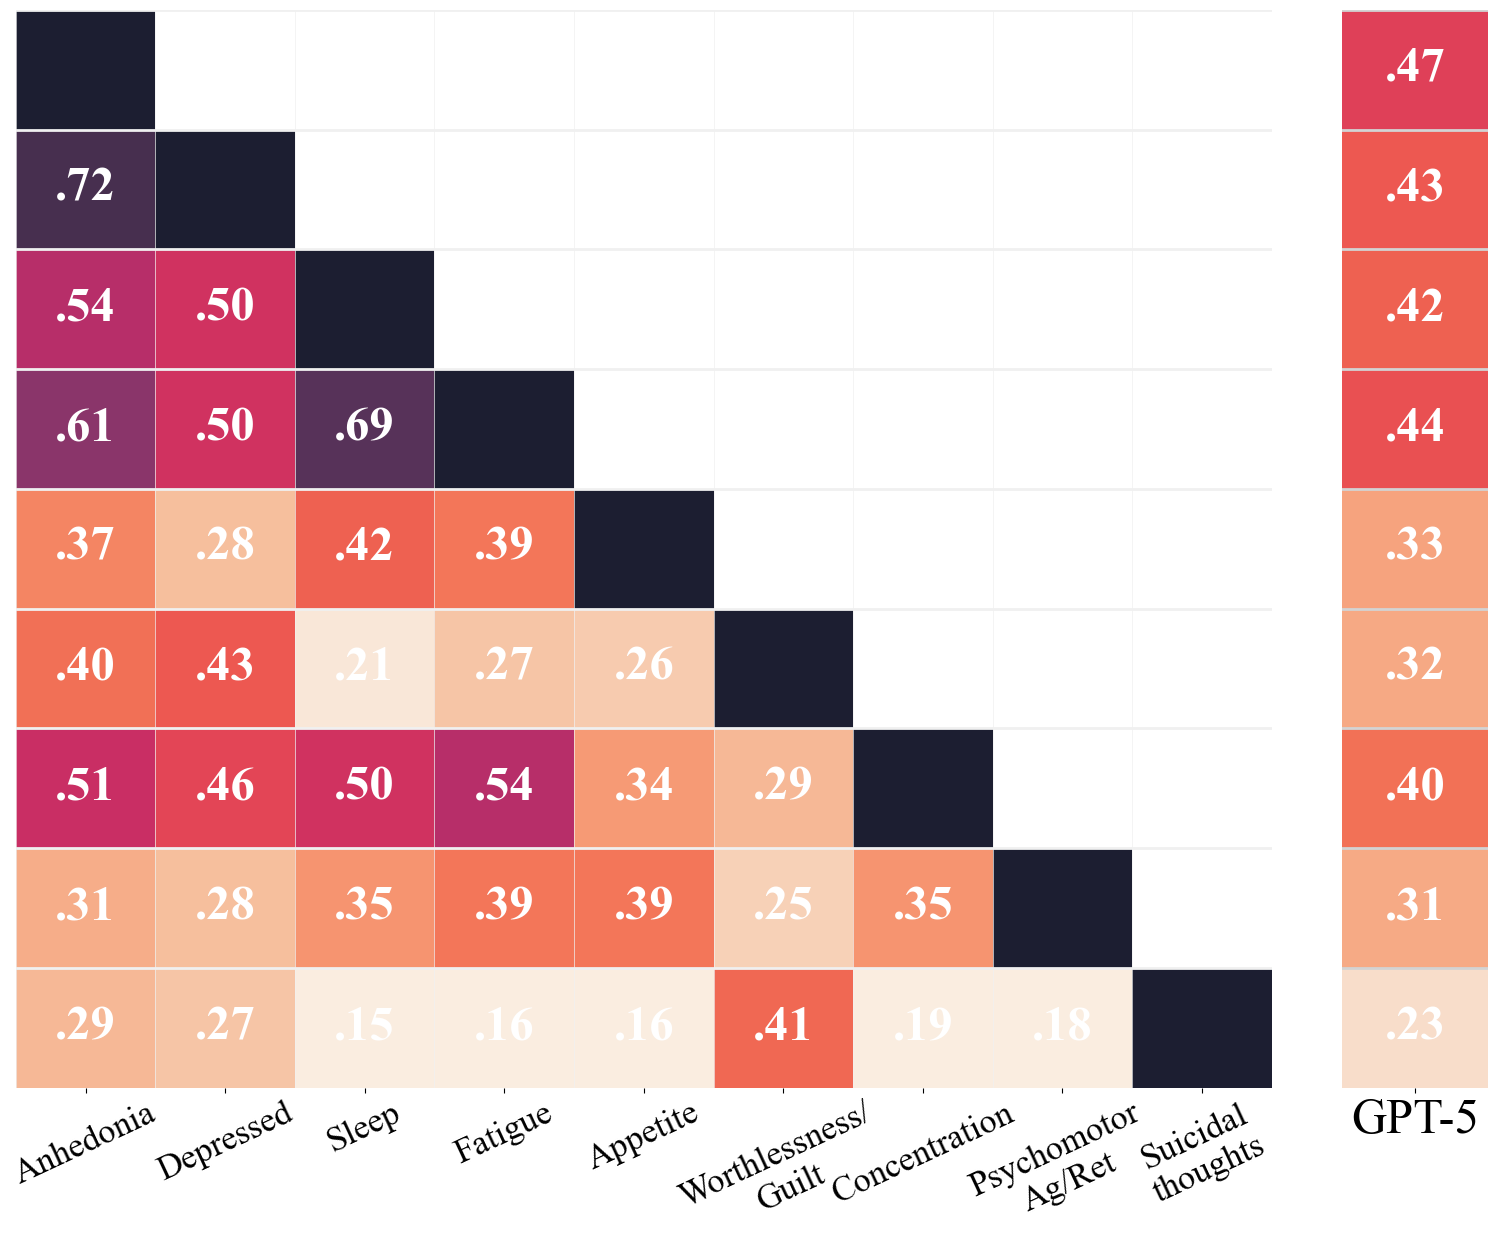

In [36]:
# Correlation in between all the items 
corr_df = gpt5_df[[i for i in score_columns]].corr().values.round(2)
corr_df_annot = gpt5_df[[i for i in score_columns]].corr().apply(lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_annot.iloc[i, i] = ''
# Turn this into sns heatmap, with x axis label rotated 35 degrees, font size of the correlation values inside the heatmap as 20

f, (a0, a1) = plt.subplots(1, 2, figsize=(19, 14), gridspec_kw={'width_ratios': [3, 0.35], 'wspace': 0.1})

mask = np.zeros_like(corr_df, dtype="bool")
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False

sns.heatmap(corr_df, annot = corr_df_annot, mask=mask, cmap='rocket_r', vmin=0.2, vmax=0.8, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'}, 
            ax=a0, cbar=False)

a0.tick_params(left=False, bottom=True)

for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)
# a0.axhline(7, color='white', lw=6)
# a0.axhline(7, color='#f0f0f0', lw=2)

tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']

a0.set_xticklabels(tick_labels, rotation=25, fontsize=25, fontproperties=custom_font)
a0.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)

avgs = ((corr_df.sum(axis=1)-1.0)/8).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:]] for row in avgs for v in row]
sns.heatmap(avgs, annot=avgs_annot, cmap='rocket_r', vmin=0.2, vmax=0.8, alpha=0.9, fmt='', ax=a1, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=False)

for i in range(9):
    a1.axhline(i, color='lightgray', lw=2)
# a1.axhline(7, color='white', lw=6)

a1.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a1.yaxis.tick_right()
a1.tick_params(right=False, bottom=True, left=False)
a1.set_xticklabels(['GPT-5'], rotation=0, fontsize=35,  fontproperties=custom_font)

# cbar = a1.collections[0].colorbar
# # Apply font properties to the colorbar's tick labels
# for label in cbar.ax.get_yticklabels():
#     label.set_fontproperties(custom_font)
# # here set the labelsize by 20
# cbar.ax.tick_params(labelsize=40)

# plt.savefig('../data/figures/gpt4_item_corr_triu.png', dpi=1040, bbox_inches='tight')
# plt.savefig('../data/figures/gpt4_item_corr_triu.svg', dpi=2080, bbox_inches='tight')
plt.show()


In [22]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as clr

In [23]:
# clrs = list(map(lambda x: (x[0]/10.0, x[1]), enumerate(['#8e0152','#c51b7d','#de77ae','#f1b6da','#fde0ef','#f7f7f7','#e6f5d0','#b8e186','#7fbc41','#4d9221','#276419'])))
clrs = list(map(lambda x: (x[0]/10.0, x[1]), enumerate(['#40004b','#762a83','#9970ab','#c2a5cf','#e7d4e8','#f7f7f7','#d9f0d3','#a6dba0','#5aae61','#1b7837','#00441b'])))
# clrs = list(map(lambda x: (x[0]/6.0, x[1]), enumerate(['#5a77d1', '#6788ee', '#9abbff', '#a9aaab', '#f7a889', '#e26952', '#c95a44'])))

# clrs = list(map(lambda x: (x[0]/7.0, x[1]), enumerate(['#5a77d1', '#9abbff', '#c9d7f0', '#aeb9cf', '#edd1c2', '#f7a889', '#e26952', '#c95a44'])))

custom_cmap = clr.LinearSegmentedColormap.from_list('custom coolwarm', clrs, N=256)

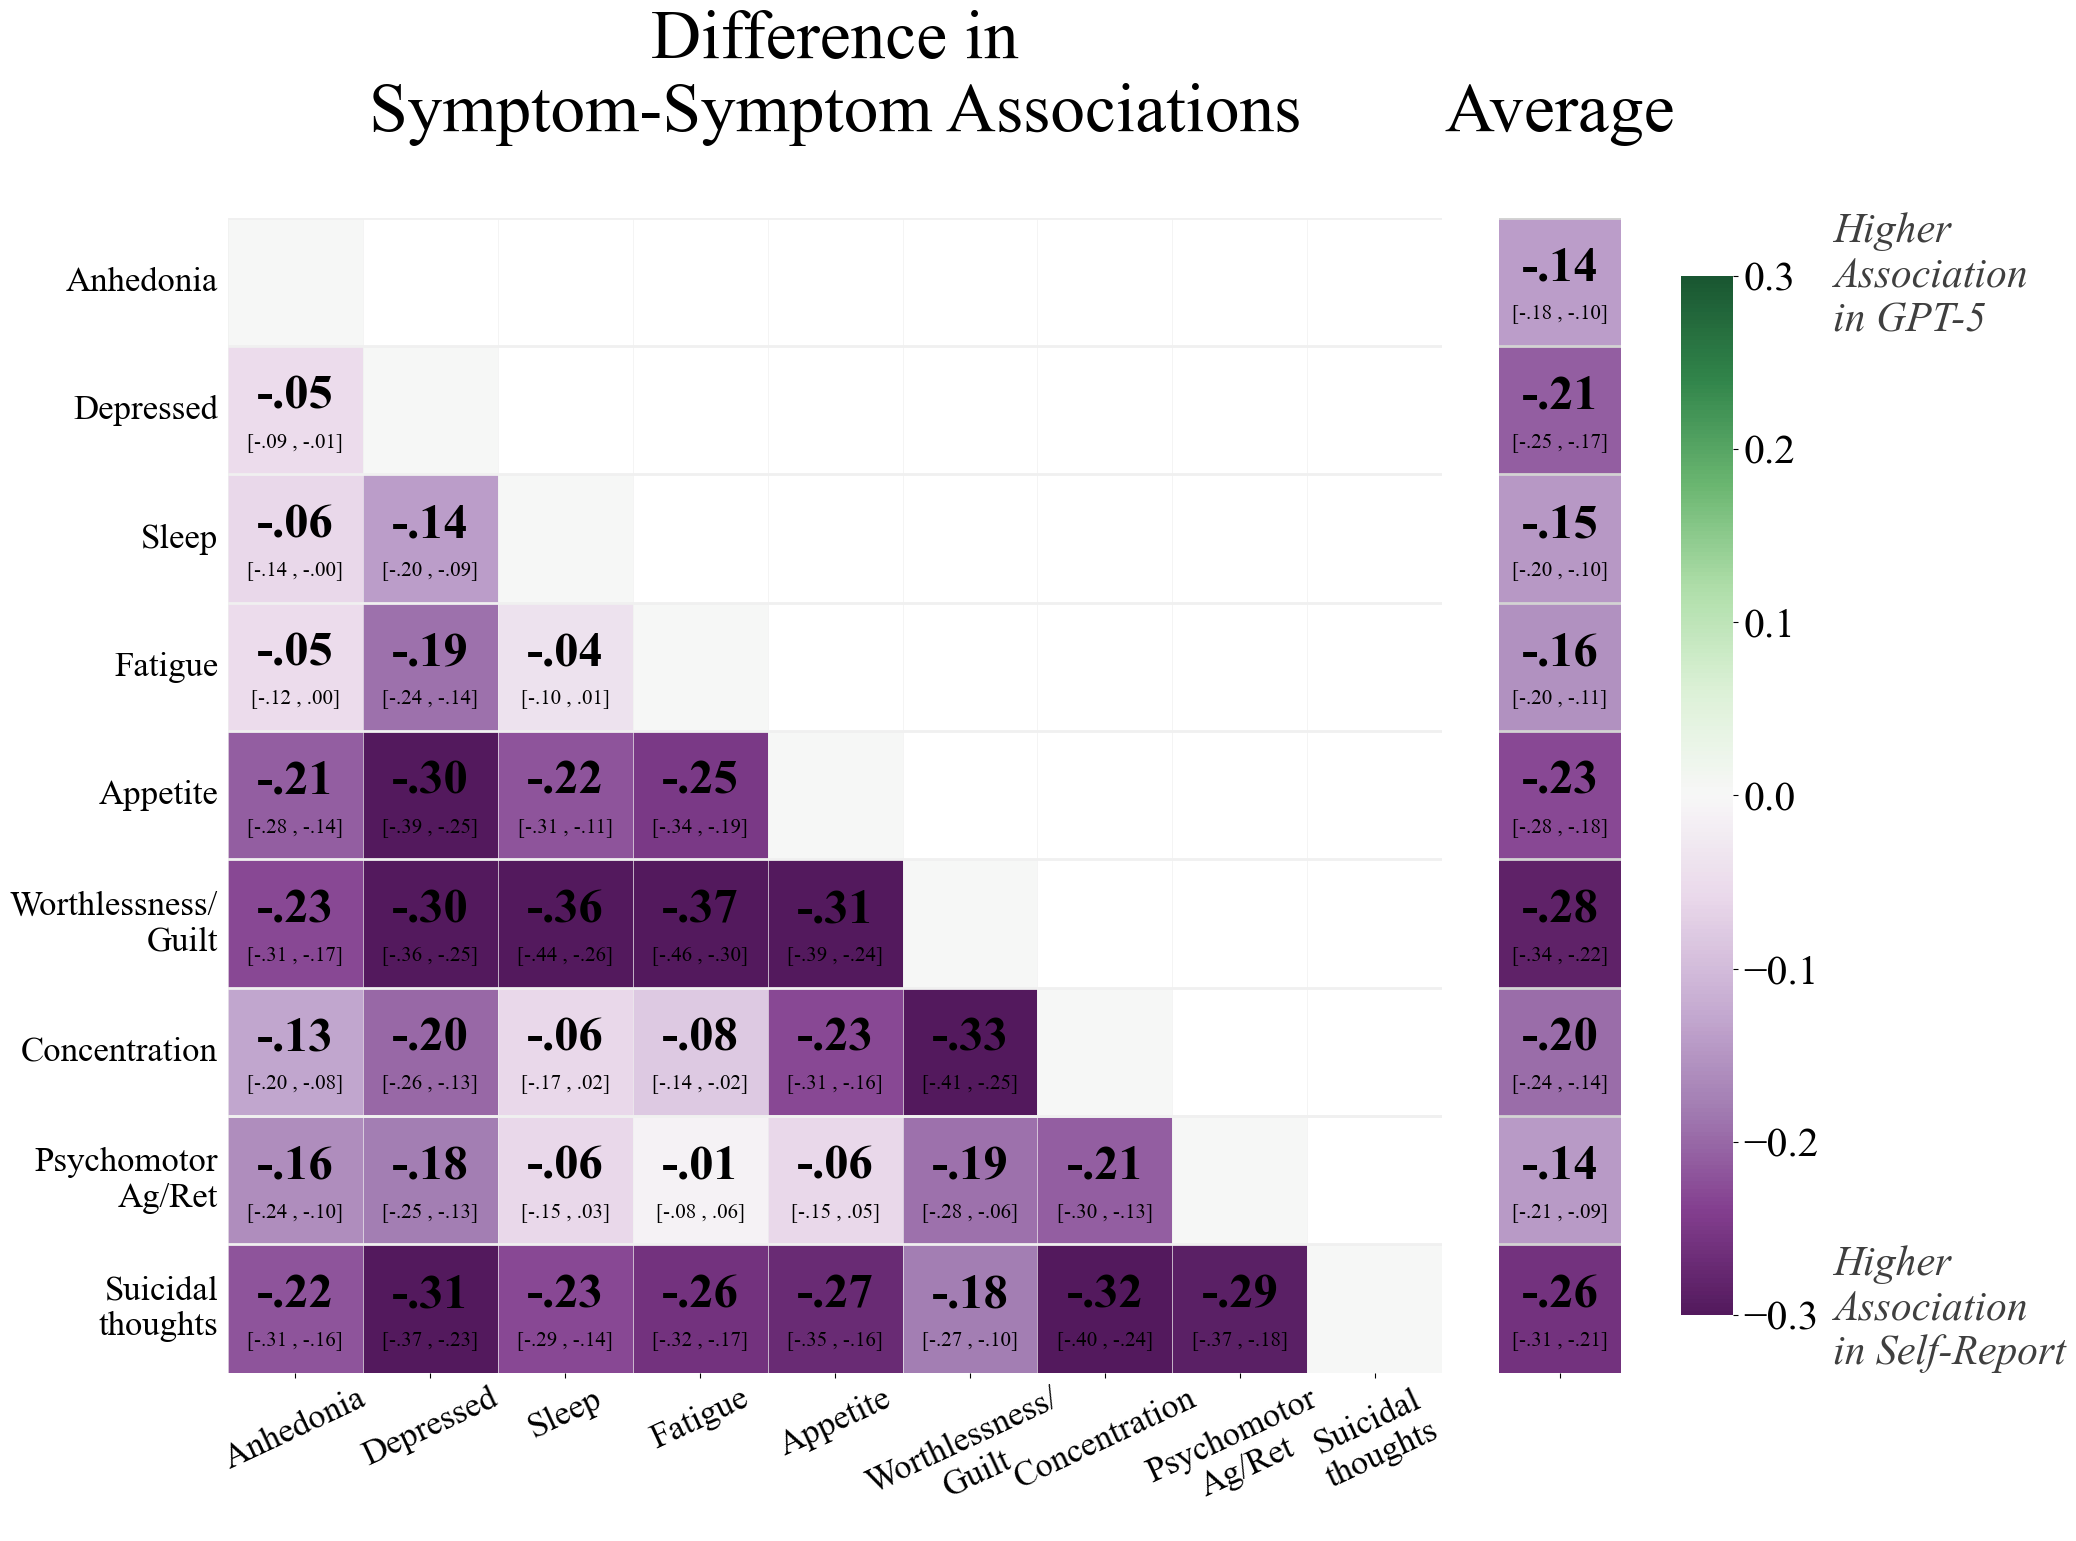

In [24]:
x_y = pd.merge(gpt5_df, self_report_df, on='user_id', suffixes=('_gpt5', '_selfreport'))
gpt5_items_corr = x_y[['{}_gpt5'.format(i) for i in score_columns]].corr()
selfreport_items_corr = x_y[['{}_selfreport'.format(i) for i in score_columns]].corr()

diff_corr = np.round(gpt5_items_corr.values - selfreport_items_corr.values, 2)
diff_corr_annot = [[f'{val:.2f}'[-3:] if val>=0 else '-'+f'{val:.2f}'[-3:] for val in row] for row in diff_corr]
for i in range(9): diff_corr_annot[i][i] = '' 

corrs_trials = []
avg_corr_trials = []
for trial in range(100):
    # sample shape[0] users with replacement
    x_y_sample = x_y.sample(n=x_y.shape[0], replace=True, random_state=trial)
    gpt5_sample_corr = x_y_sample[[f'{i}_gpt5' for i in score_columns]].corr()\
                        .rename(columns={f'{i}_gpt5':i for i in score_columns}, 
                                index={f'{i}_gpt5':i for i in score_columns})
    sr_sample_corr = x_y_sample[[f'{i}_selfreport' for i in score_columns]].corr()\
                        .rename(columns={f'{i}_selfreport':i for i in score_columns}, 
                                index={f'{i}_selfreport':i for i in score_columns})
    sample = gpt5_sample_corr - sr_sample_corr
    # calculate the correlation matrix
    diff_corr_df = sample.values.round(2)
    # append to corrs_trials
    corrs_trials.append(diff_corr_df)
    avg_sample = (diff_corr_df.sum(axis=1)/8.0).reshape(-1, 1)
    avg_corr_trials.append(avg_sample)

# create a 3D array of the correlation matrices
corrs_trials = np.array(corrs_trials)
avg_corr_trials = np.array(avg_corr_trials)
# sort along the trials axis and take the 2.5th and 97.5th percentiles
lower_bound = np.percentile(corrs_trials, 2.5, axis=0)
upper_bound = np.percentile(corrs_trials, 97.5, axis=0)
avg_lower_bound = np.percentile(avg_corr_trials, 2.5, axis=0)
avg_upper_bound = np.percentile(avg_corr_trials, 97.5, axis=0)

# annotate the corr_df_annot with [lower_bound, upper_bound] below the correlation values in smaller font
conf_bounds_annot = corr_df_annot.copy()
for idx in range(9):
    for jdx in range(9):
        if idx != jdx:
            lwr_bound_annot = f'{lower_bound[idx, jdx]:.2f}'[-3:] if lower_bound[idx, jdx]>=0 else '-'+f'{lower_bound[idx, jdx]:.2f}'[-3:]
            upr_bound_annot = f'{upper_bound[idx, jdx]:.2f}'[-3:] if upper_bound[idx, jdx]>=0 else '-'+f'{upper_bound[idx, jdx]:.2f}'[-3:]
            conf_bounds_annot.iloc[idx, jdx] = '['+lwr_bound_annot+' , '+ upr_bound_annot+']'

conf_bounds_avg_annot = []
for i in range(9):
    lower_bound_annot = f'{avg_lower_bound[i][0]:.2f}'[-3:] if avg_lower_bound[i][0]>=0 else '-'+f'{avg_lower_bound[i][0]:.2f}'[-3:]
    upper_bound_annot = f'{avg_upper_bound[i][0]:.2f}'[-3:] if avg_upper_bound[i][0]>=0 else '-'+f'{avg_upper_bound[i][0]:.2f}'[-3:]
    conf_bounds_avg_annot.append('['+lower_bound_annot+' , '+ upper_bound_annot+']')

mask = np.zeros_like(diff_corr, dtype="bool")
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False


f = plt.figure(figsize=(21, 15))
gs1 = gridspec.GridSpec(1, 2, figure=f, right=0.875, width_ratios=[0.80, 0.20], wspace=0.075)
# gs2 = gridspec.GridSpec(1, 2, figure=f, left=0.82, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.1)

a0 = f.add_subplot(gs1[0])
a1 = f.add_subplot(gs1[1])


sns.heatmap(diff_corr, annot=False, mask=mask, cmap=custom_cmap, vmin=-.3, vmax=.3, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'black'}, 
            ax=a0, cbar=False)

# Add custom annotations
for i in range(9):
    for j in range(9):
        if not mask[i, j]:
            corr_text = f'{diff_corr_annot[i][j]}'
            conf_bounds = conf_bounds_annot.iloc[i, j]
            
            a0.text(j + 0.5, i + 0.4, corr_text, ha='center', va='center',
                    fontsize=35, fontweight='bold', color='black', fontproperties=custom_font_bold)
            if i!= j:
                a0.text(j + 0.5, i + 0.75, conf_bounds, ha='center', va='center',
                    fontsize=15, color='black', fontproperties=custom_font)


a0.tick_params(left=False, bottom=True)

for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)
# a0.axhline(7, color='white', lw=6)
a0.axhline(7, color='#f0f0f0', lw=2)

tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']

a0.set_xticklabels(tick_labels, rotation=25, fontsize=25, fontproperties=custom_font)
a0.set_yticklabels(tick_labels_y, rotation=0, fontsize=25,  fontproperties=custom_font)

avgs = (diff_corr.sum(axis=1)/8.0).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:] if v>=0 else '-'+f'{v:.2f}'[-3:] for v in row] for row in avgs]

sns.heatmap(avgs, annot=False, cmap=custom_cmap, vmin=-0.3, vmax=0.3, alpha=0.9, fmt='', ax=a1, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'black'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=True)

for i in range(9):
    corr_text = avgs_annot[i][0]
    conf_bounds = conf_bounds_avg_annot[i]
    a1.text(0.5, i + 0.4, corr_text, ha='center', va='center',
            fontsize=35, fontweight='bold', color='black', fontproperties=custom_font_bold)
    a1.text(0.5, i + 0.75, conf_bounds, ha='center', va='center',
            fontsize=15, color='black', fontproperties=custom_font)
    a1.axhline(i, color='lightgray', lw=2)
# a1.axhline(7, color='white', lw=6)

a1.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a1.yaxis.tick_right()
a1.tick_params(right=False, bottom=True, left=False)
a1.set_xticklabels([''], rotation=0, fontsize=35,  fontproperties=custom_font)

cbar = a1.collections[0].colorbar
# Apply font properties to the colorbar's tick labels
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(custom_font)
# here set the labelsize by 20
cbar.ax.tick_params(labelsize=30)

a1.text(2.75, 0.45, 'Higher\nAssociation\nin GPT-5', ha='left', va='center', fontsize=30, fontproperties=custom_font_italics, color='#3f3f3f')
a1.text(2.75, 8.5, 'Higher\nAssociation\nin Self-Report', ha='left', va='center', fontsize=30, fontproperties=custom_font_italics, color='#3f3f3f')

# # Add ghost axes and titles on gs1 and gs2
# ax_left = f.add_subplot(gs1[:])
# ax_left.axis('off')
a0.set_title('Difference in\nSymptom-Symptom Associations\n', fontsize=50, fontproperties=custom_font)

# ax_right = f.add_subplot(gs2[:])
# ax_right.axis('off')
a1.set_title('Average\n', fontsize=50, fontproperties=custom_font)



# plt.savefig('../data/figures/diff_gpt4_sr_corr_triu.png', dpi=1040, bbox_inches='tight')
# plt.savefig('../data/figures/diff_gpt5_sr_corr_triu.pdf', dpi=1040, bbox_inches='tight')
plt.show()
# save figure


Pairs surviving BH correction (q=0.05): 31 / 36
  Depressed x Anhedonia  diff=-0.05  p=0.006
  Sleep x Anhedonia  diff=-0.06  p=0.040
  Sleep x Depressed  diff=-0.14  p=0.000
  Fatigue x Anhedonia  diff=-0.05  p=0.040
  Fatigue x Depressed  diff=-0.19  p=0.000
  Appetite x Anhedonia  diff=-0.21  p=0.000
  Appetite x Depressed  diff=-0.30  p=0.000
  Appetite x Sleep  diff=-0.22  p=0.000
  Appetite x Fatigue  diff=-0.25  p=0.000
  Worthlessness/Guilt x Anhedonia  diff=-0.23  p=0.000
  Worthlessness/Guilt x Depressed  diff=-0.30  p=0.000
  Worthlessness/Guilt x Sleep  diff=-0.36  p=0.000
  Worthlessness/Guilt x Fatigue  diff=-0.37  p=0.000
  Worthlessness/Guilt x Appetite  diff=-0.31  p=0.000
  Concentration x Anhedonia  diff=-0.13  p=0.000
  Concentration x Depressed  diff=-0.20  p=0.000
  Concentration x Fatigue  diff=-0.08  p=0.022
  Concentration x Appetite  diff=-0.23  p=0.000
  Concentration x Worthlessness/Guilt  diff=-0.33  p=0.000
  Psychomotor x Anhedonia  diff=-0.16  p=0.000
  

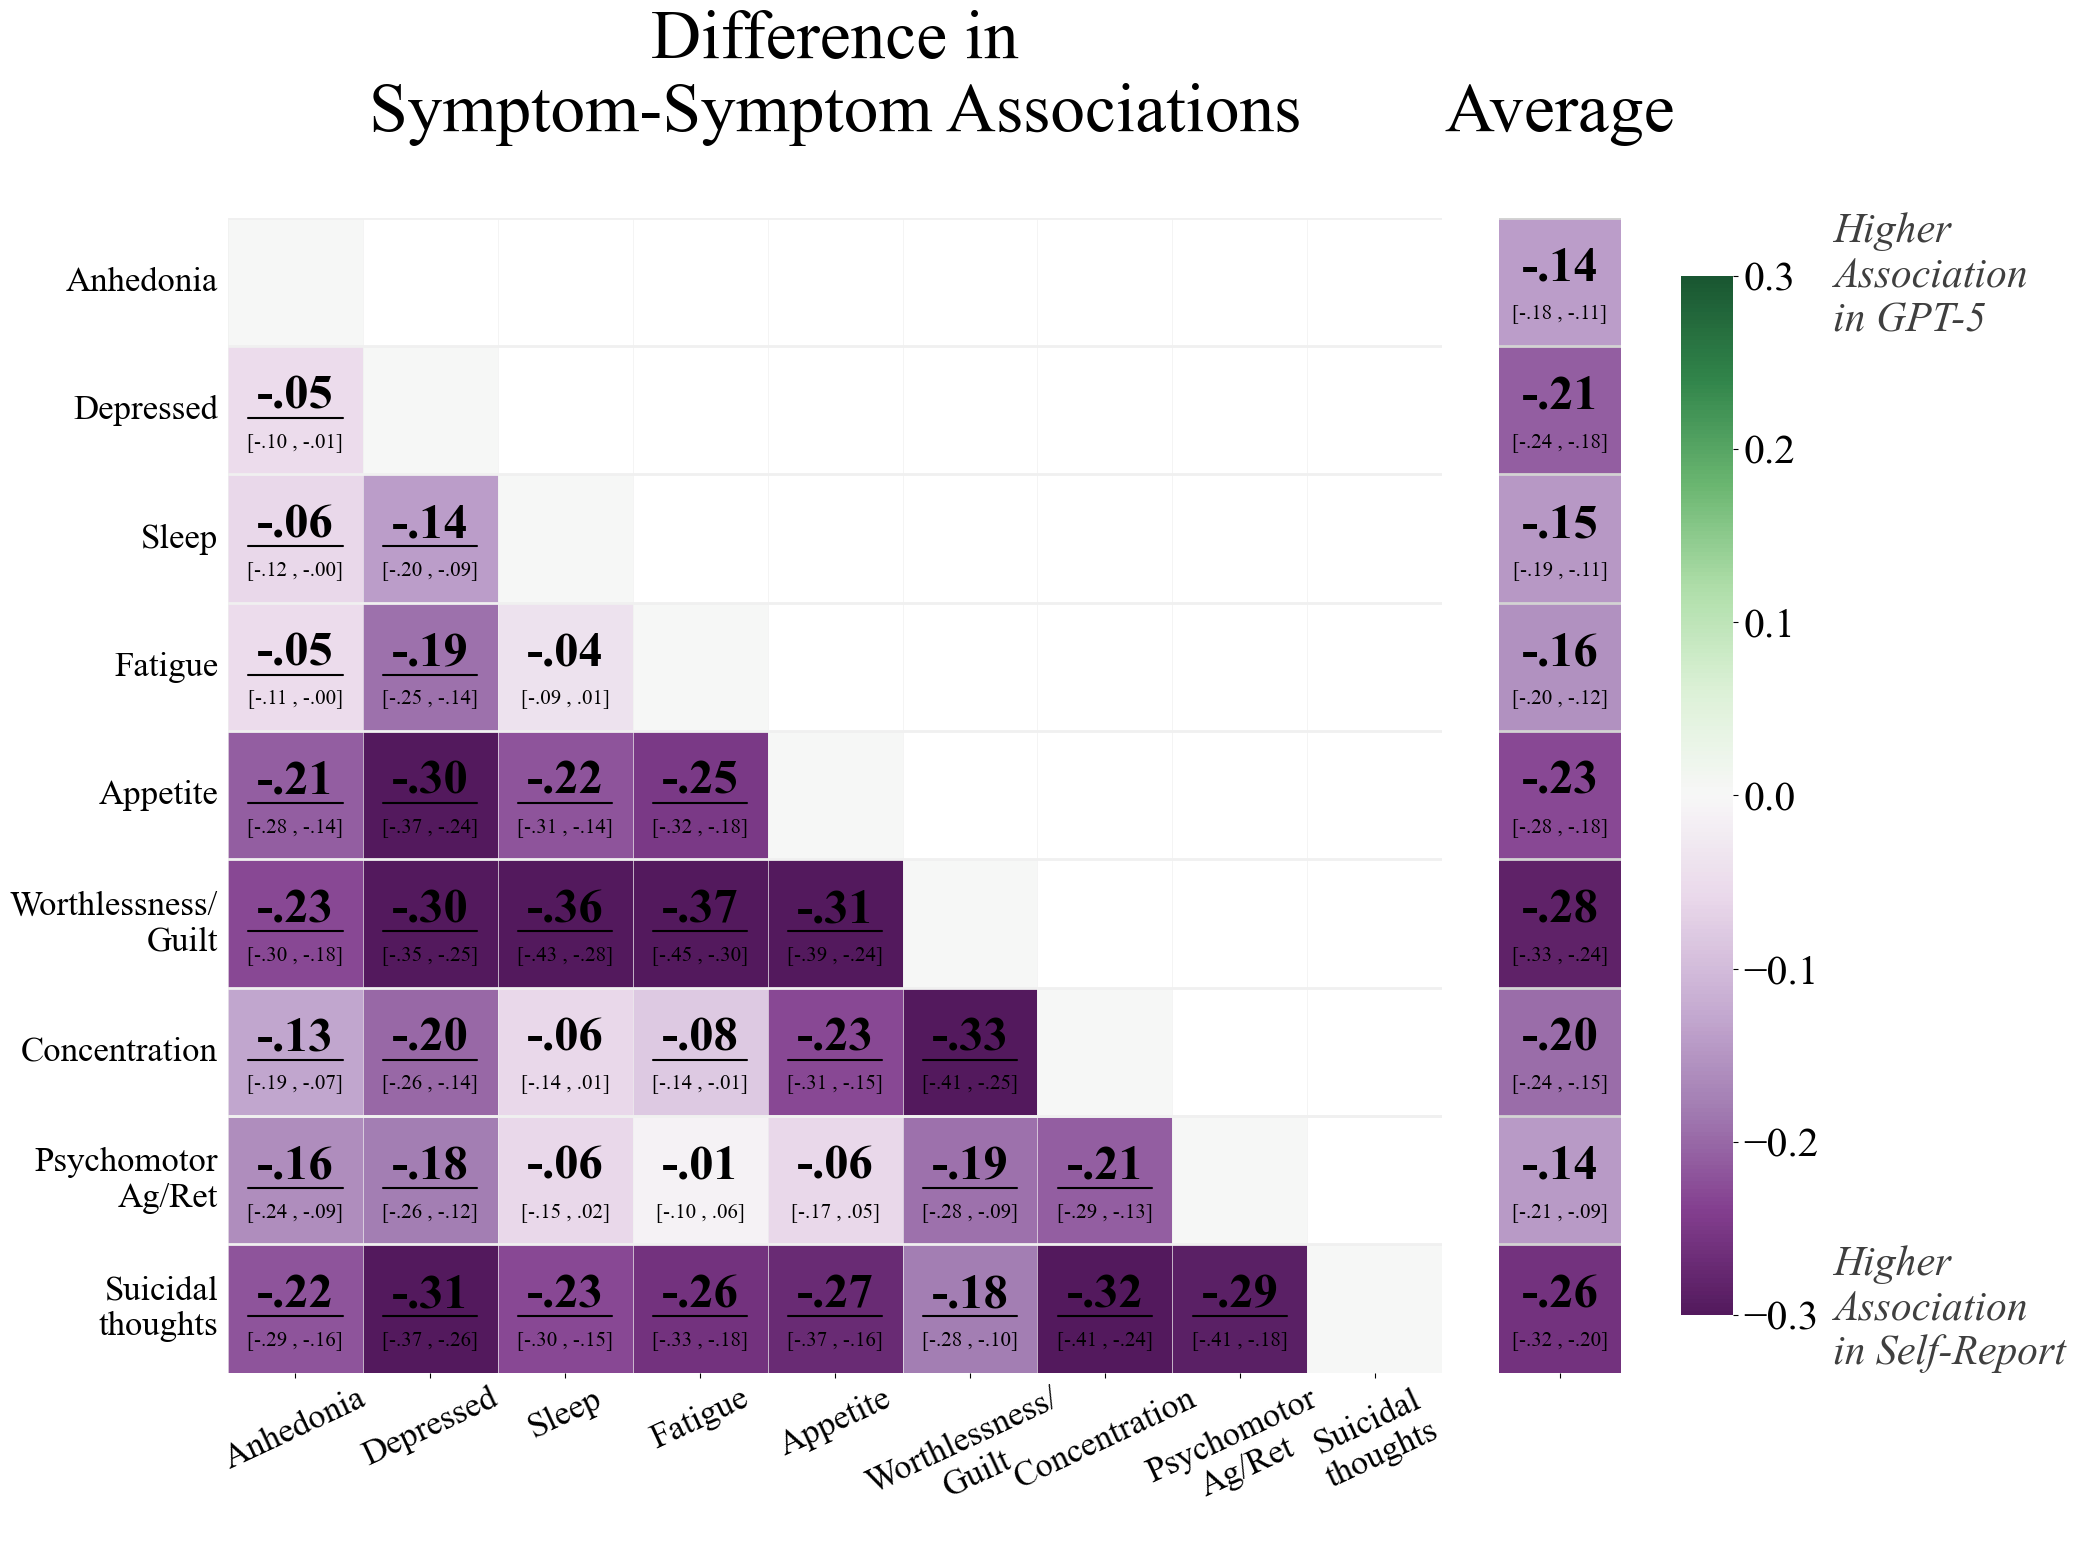

In [26]:
# ============================================================
# BH CORRECTION — FULLY SELF-CONTAINED (1000 bootstrap trials)
# ============================================================
# This cell is independent of the cell above. It recomputes the
# correlation difference matrix, bootstrap CIs, and p-values all
# from the same 1000-trial bootstrap so the trial count is internally
# consistent throughout.
#
# 1000 trials are required because BH correction at q=0.05 across
# 36 comparisons sets thresholds as stringent as 0.05×1/36 ≈ 0.0014.
# With 100 trials (min p = 0.02) those thresholds are unresolvable.
# With 1000 trials the minimum resolvable p-value is 0.002.
# ============================================================

# --- Point estimates ---
_x_y = pd.merge(gpt5_df, self_report_df, on='user_id', suffixes=('_gpt5', '_selfreport'))
_gpt5_corr  = _x_y[[f'{i}_gpt5'       for i in score_columns]].corr()
_sr_corr    = _x_y[[f'{i}_selfreport' for i in score_columns]].corr()

_diff_corr = np.round(_gpt5_corr.values - _sr_corr.values, 2)
_diff_corr_annot = [[f'{v:.2f}'[-3:] if v >= 0 else '-' + f'{v:.2f}'[-3:]
                     for v in row] for row in _diff_corr]
for _i in range(9): _diff_corr_annot[_i][_i] = ''

# --- 1000-trial bootstrap: CIs and per-trial diff matrices ---
_corrs_trials = []
_avg_corr_trials = []
for _trial in range(1000):
    _samp = _x_y.sample(n=_x_y.shape[0], replace=True, random_state=_trial)
    _g = _samp[[f'{i}_gpt5' for i in score_columns]].corr()\
          .rename(columns={f'{i}_gpt5': i for i in score_columns},
                  index={f'{i}_gpt5': i for i in score_columns})
    _s = _samp[[f'{i}_selfreport' for i in score_columns]].corr()\
          .rename(columns={f'{i}_selfreport': i for i in score_columns},
                  index={f'{i}_selfreport': i for i in score_columns})
    _d = (_g - _s).values.round(4)
    _corrs_trials.append(_d)
    _avg_corr_trials.append((_d.sum(axis=1) / 8.0).reshape(-1, 1))

_corrs_trials    = np.array(_corrs_trials)      # (1000, 9, 9)
_avg_corr_trials = np.array(_avg_corr_trials)   # (1000, 9, 1)

_lower  = np.percentile(_corrs_trials,    2.5, axis=0)
_upper  = np.percentile(_corrs_trials,   97.5, axis=0)
_avg_lo = np.percentile(_avg_corr_trials, 2.5, axis=0)
_avg_hi = np.percentile(_avg_corr_trials,97.5, axis=0)

def _fmt(v): return f'{v:.2f}'[-3:] if v >= 0 else '-' + f'{v:.2f}'[-3:]

_conf_bounds_annot = pd.DataFrame(index=score_columns, columns=score_columns, dtype=str)
for _i in range(9):
    for _j in range(9):
        if _i != _j:
            _conf_bounds_annot.iloc[_i, _j] = '[' + _fmt(_lower[_i,_j]) + ' , ' + _fmt(_upper[_i,_j]) + ']'

_conf_bounds_avg_annot = [
    '[' + _fmt(_avg_lo[_i][0]) + ' , ' + _fmt(_avg_hi[_i][0]) + ']'
    for _i in range(9)
]

# --- Bootstrap p-values (same 1000-trial distribution) ---
# H0: r_gpt5_ij == r_sr_ij  (two-tailed)
# p_ij = 2 * min(fraction of boot diffs <= 0, fraction >= 0)
_lower_tri_pairs = [(i, j) for i in range(9) for j in range(i)]
_pval_matrix = np.ones((9, 9))
for _i, _j in _lower_tri_pairs:
    _boot = _corrs_trials[:, _i, _j]
    _p = 2.0 * min(np.mean(_boot <= 0), np.mean(_boot >= 0))
    _pval_matrix[_i, _j] = _p
    _pval_matrix[_j, _i] = _p  # symmetric

# --- Benjamini-Hochberg FDR correction (q = 0.05, 36 comparisons) ---
def _bh_correction(pvals, alpha=0.05):
    """Returns boolean array: True = H0 rejected after BH correction."""
    n = len(pvals)
    order = np.argsort(pvals)
    below = pvals[order] <= (alpha * np.arange(1, n + 1) / n)
    if not below.any():
        return np.zeros(n, dtype=bool)
    rejected = np.zeros(n, dtype=bool)
    rejected[order[:np.where(below)[0][-1] + 1]] = True
    return rejected

_pvals_flat  = np.array([_pval_matrix[i, j] for i, j in _lower_tri_pairs])
_bh_rejected = _bh_correction(_pvals_flat, alpha=0.05)

# sig_matrix: True where the lower-triangle pair survives BH (used to draw underline)
_sig_matrix = np.zeros((9, 9), dtype=bool)
for _k, (_i, _j) in enumerate(_lower_tri_pairs):
    if _bh_rejected[_k]:
        _sig_matrix[_i, _j] = True

_sym_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite',
               'Worthlessness/Guilt', 'Concentration', 'Psychomotor', 'Suicidal']
_n_sig = int(_sig_matrix[np.tril_indices(9, k=-1)].sum())
print(f"Pairs surviving BH correction (q=0.05): {_n_sig} / 36")
for _i, _j in _lower_tri_pairs:
    if _sig_matrix[_i, _j]:
        print(f"  {_sym_labels[_i]} x {_sym_labels[_j]}"
              f"  diff={_diff_corr[_i,_j]:.2f}  p={_pval_matrix[_i,_j]:.3f}")

# ============================================================
# FIGURE (1000-trial CIs + BH underlines on significant cells)
# ============================================================
_mask = np.zeros_like(_diff_corr, dtype='bool')
_mask[np.triu_indices_from(_mask)] = True
_mask[np.diag_indices_from(_mask)] = False

_avgs = (_diff_corr.sum(axis=1) / 8.0).reshape(-1, 1)
_avgs_annot = [[_fmt(v) for v in row] for row in _avgs]

f = plt.figure(figsize=(21, 15))
gs1 = gridspec.GridSpec(1, 2, figure=f, right=0.875, width_ratios=[0.80, 0.20], wspace=0.075)
a0 = f.add_subplot(gs1[0])
a1 = f.add_subplot(gs1[1])

sns.heatmap(_diff_corr, annot=False, mask=_mask, cmap=custom_cmap,
            vmin=-.3, vmax=.3, alpha=0.9, fmt='',
            annot_kws={'fontsize': 35, 'fontweight': 'bold',
                       'fontproperties': custom_font_bold, 'color': 'black'},
            ax=a0, cbar=False)

for _i in range(9):
    for _j in range(9):
        if not _mask[_i, _j]:
            a0.text(_j + 0.5, _i + 0.4, f'{_diff_corr_annot[_i][_j]}',
                    ha='center', va='center', fontsize=35, fontweight='bold',
                    color='black', fontproperties=custom_font_bold)
            if _i != _j:
                a0.text(_j + 0.5, _i + 0.75, _conf_bounds_annot.iloc[_i, _j],
                        ha='center', va='center', fontsize=15,
                        color='black', fontproperties=custom_font)

            # --- BH significance marker ---
            # Thin underline drawn beneath the correlation value for pairs that
            # survive Benjamini-Hochberg correction at q=0.05 (36 comparisons,
            # 1000-trial bootstrap p-values).
            if _sig_matrix[_i, _j]:
                a0.plot([_j + 0.15, _j + 0.85], [_i + 0.56, _i + 0.56],
                        color='black', linewidth=1.5, solid_capstyle='round',
                        transform=a0.transData, clip_on=True)

a0.tick_params(left=False, bottom=True)
for _i in range(9):
    a0.axhline(_i, color='#f0f0f0', lw=2)
    a0.axvline(_i, color='#f0f0f0', lw=.5)
a0.axhline(7, color='#f0f0f0', lw=2)

_tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite',
                'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']
a0.set_xticklabels(_tick_labels, rotation=25, fontsize=25, fontproperties=custom_font)
a0.set_yticklabels(_tick_labels, rotation=0,  fontsize=25, fontproperties=custom_font)

sns.heatmap(_avgs, annot=False, cmap=custom_cmap, vmin=-0.3, vmax=0.3,
            alpha=0.9, fmt='', ax=a1,
            annot_kws={'fontsize': 35, 'fontweight': 'bold',
                       'fontproperties': custom_font_bold, 'color': 'black'},
            cbar_kws={'fraction': 0.4, 'shrink': 0.9, 'pad': 0.2}, cbar=True)

for _i in range(9):
    a1.text(0.5, _i + 0.4, _avgs_annot[_i][0], ha='center', va='center',
            fontsize=35, fontweight='bold', color='black', fontproperties=custom_font_bold)
    a1.text(0.5, _i + 0.75, _conf_bounds_avg_annot[_i], ha='center', va='center',
            fontsize=15, color='black', fontproperties=custom_font)
    a1.axhline(_i, color='lightgray', lw=2)

a1.set_yticklabels([], rotation=0, fontsize=27, fontproperties=custom_font)
a1.yaxis.tick_right()
a1.tick_params(right=False, bottom=True, left=False)
a1.set_xticklabels([''], rotation=0, fontsize=35, fontproperties=custom_font)

cbar = a1.collections[0].colorbar
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(custom_font)
cbar.ax.tick_params(labelsize=30)

a1.text(2.75, 0.45, 'Higher\nAssociation\nin GPT-5', ha='left', va='center',
        fontsize=30, fontproperties=custom_font_italics, color='#3f3f3f')
a1.text(2.75, 8.5, 'Higher\nAssociation\nin Self-Report', ha='left', va='center',
        fontsize=30, fontproperties=custom_font_italics, color='#3f3f3f')

a0.set_title('Difference in\nSymptom-Symptom Associations\n', fontsize=50, fontproperties=custom_font)
a1.set_title('Average\n', fontsize=50, fontproperties=custom_font)

# plt.savefig('../data/figures/diff_gpt5_sr_corr_triu_bh.pdf', dpi=1040, bbox_inches='tight')
plt.show()


## IRT

In [16]:
import pickle5 as pickle
from scipy import stats
import numpy as np
import pandas as pd

PATH_TO_JSON = '/cronus_data/avirinchipur/reasoning_for_psych/irt/gpt5_sr_fulldata_ranking.pkl'
combined_data_symp_rank = pickle.load(open(PATH_TO_JSON, 'rb'))

In [17]:
combined_data_symp_rank['gpt5'].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [18]:
gpt5_symp_ranks_all = []
self_symp_ranks_all = []
for i in range(9):
    gpt5_symp_ranks_all.append(np.array(combined_data_symp_rank['gpt5'][i]))
    self_symp_ranks_all.append(np.array(combined_data_symp_rank['self_report'][i]))

gpt5_symp_ranks_all = np.array(gpt5_symp_ranks_all)
self_symp_ranks_all = np.array(self_symp_ranks_all)

print ("Shapes: ", gpt5_symp_ranks_all.shape, self_symp_ranks_all.shape)

spearman_corr = []
kendall_corr = []
for i in range(gpt5_symp_ranks_all.shape[1]):
    spearman_corr.append(stats.spearmanr(gpt5_symp_ranks_all[:,i], self_symp_ranks_all[:,i]))
    kendall_corr.append(stats.kendalltau(gpt5_symp_ranks_all[:,i], self_symp_ranks_all[:,i]))
    
# Report the 95% confidence interval of the Spearman correlation
spearman_corr = np.array(spearman_corr)[:, 0]
kendall_corr = np.array(kendall_corr)[:, 0]
print (f"95% confidence interval of Spearman correlation: {np.percentile(spearman_corr, 5).round(3)} - {np.percentile(spearman_corr, 95).round(3)}")
print (f"95% confidence interval of Kendall correlation: {np.percentile(kendall_corr, 5).round(3)} - {np.percentile(kendall_corr, 95).round(3)}")


Shapes:  (9, 500) (9, 500)
95% confidence interval of Spearman correlation: 0.817 - 0.9
95% confidence interval of Kendall correlation: 0.556 - 0.778


In [19]:
colnames = ['score_Anhedonia', 'score_Depressed_Mood', 'score_Insomnia_or_Hypersomnia', 'score_Fatigue', \
        'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt', 'score_Difficulty_concentrating', \
        'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation']

In [26]:
# Compute 95% confidence interval of the ranks of each symptom 
rank_bounds = {}
for i in range(9):
    gpt5_rank = gpt5_symp_ranks_all[i]
    self_rank = self_symp_ranks_all[i]
    gpt5_rank_stderr = (np.std(gpt5_rank) / np.sqrt(len(gpt5_rank))).round(2)
    self_rank_stderr = (np.std(self_rank) / np.sqrt(len(self_rank))).round(2)
    rank_bounds[colnames[i]] = [np.percentile(gpt5_rank, 2.5), np.percentile(gpt5_rank, 97.5), #gpt5_rank_stderr, 
                                np.percentile(self_rank, 2.5), np.percentile(self_rank, 97.5)#, self_rank_stderr
                                ]

10-pd.DataFrame(rank_bounds, index=['gpt5_upr', 'gpt5_lwr', 'Self_upr', 'Self_lwr']).T

,gpt5_upr,gpt5_lwr,Self_upr,Self_lwr
score_Anhedonia,2.000,2.0,3.0,3.0
score_Depressed_Mood,1.000,1.0,2.0,1.0
score_Insomnia_or_Hypersomnia,6.000,4.0,6.0,4.0
score_Fatigue,3.000,3.0,2.0,1.0
score_Poor_appetite_or_overeating,9.000,8.0,7.0,7.0
score_Worthlessness_or_Guilt,6.000,4.0,6.0,4.0
score_Difficulty_concentrating,6.000,4.0,6.0,4.0
score_Psychomotor_agitation_or_retardation,9.000,8.0,8.0,8.0
score_Suicidal_ideation,7.525,7.0,9.0,9.0


In [30]:
fulldata_ranks = pd.read_csv('/cronus_data/avirinchipur/reasoning_for_psych/irt/gpt5_sr_fulldata_ranking.csv')
fulldata_ranks

,gpt5,self_report,columns
0,8.0,7.0,score_Anhedonia
1,9.0,8.0,score_Depressed_Mood
2,4.0,6.0,score_Insomnia_or_Hypersomnia
3,7.0,9.0,score_Fatigue
4,1.0,3.0,score_Poor_appetite_or_overeating
5,6.0,5.0,score_Worthlessness_or_Guilt
6,5.0,4.0,score_Difficulty_concentrating
7,2.0,2.0,score_Psychomotor_agitation_or_retardation
8,3.0,1.0,score_Suicidal_ideation


In [34]:
10-fulldata_ranks.set_index('columns').astype(int)

,gpt5,self_report
columns,,
score_Anhedonia,2,3
score_Depressed_Mood,1,2
score_Insomnia_or_Hypersomnia,6,4
score_Fatigue,3,1
score_Poor_appetite_or_overeating,9,7
score_Worthlessness_or_Guilt,4,5
score_Difficulty_concentrating,5,6
score_Psychomotor_agitation_or_retardation,8,8
score_Suicidal_ideation,7,9


## Explicit and Implicit Items

In [48]:
symptoms_columns = ['Anhedonia', 'Depressed_Mood', 'Insomnia_or_Hypersomnia',
       'Fatigue', 'Poor_appetite_or_overeating', 'Worthlessness_or_Guilt',
       'Difficulty_concentrating', 'Psychomotor_agitation_or_retardation',
       'Suicidal_ideation']
       
score_columns = ['score_Anhedonia', 'score_Depressed_Mood',
       'score_Insomnia_or_Hypersomnia', 'score_Fatigue',
       'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt',
       'score_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation']

isInferred_columns = ['isInferred_Anhedonia', 'isInferred_Depressed_Mood',
         'isInferred_Insomnia_or_Hypersomnia', 'isInferred_Fatigue',
         'isInferred_Poor_appetite_or_overeating',
         'isInferred_Worthlessness_or_Guilt',
         'isInferred_Difficulty_concentrating',
         'isInferred_Psychomotor_agitation_or_retardation',
         'isInferred_Suicidal_ideation']

spans_columns = ['spans_Anhedonia', 'spans_Depressed_Mood',
       'spans_Insomnia_or_Hypersomnia', 'spans_Fatigue',
       'spans_Poor_appetite_or_overeating', 'spans_Worthlessness_or_Guilt',
       'spans_Difficulty_concentrating',
       'spans_Psychomotor_agitation_or_retardation', 'spans_Suicidal_ideation']

In [49]:
# Caluclate the correlation between gpt4 and self report for each symptom under two conditions, 
# 1. considering only the explicit occurences
# 2. considering only implicit occurences

gpt5_sr_exp_imp_pearsonr = []
for symptom in symptoms_columns:
    exp_rows = gpt5_df[gpt5_df['isInferred_'+symptom] == 0].user_id.tolist()
    imp_rows = gpt5_df[gpt5_df['isInferred_'+symptom] == 1].user_id.tolist()
    symptom_scores = 'score_' + symptom
    gpt5_sr_merge_exp = gpt5_df[gpt5_df['user_id'].isin(exp_rows)][['user_id', symptom_scores]].merge(self_report_df[['user_id', symptom_scores]], on='user_id')
    gpt5_sr_merge_imp = gpt5_df[gpt5_df['user_id'].isin(imp_rows)][['user_id', symptom_scores]].merge(self_report_df[['user_id', symptom_scores]], on='user_id')
    exp_pearsonr, _ = pearsonr(gpt5_sr_merge_exp[symptom_scores+'_x'], gpt5_sr_merge_exp[symptom_scores+'_y'])
    imp_pearsonr, _ = pearsonr(gpt5_sr_merge_imp[symptom_scores+'_x'], gpt5_sr_merge_imp[symptom_scores+'_y'])
    temp = [symptom, round(100*len(exp_rows)/gpt5_df.shape[0], 2), round(exp_pearsonr, 2), round(100*len(imp_rows)/gpt5_df.shape[0], 2), round(imp_pearsonr, 2)]
    gpt5_sr_exp_imp_pearsonr.append(temp)

pd.DataFrame(gpt5_sr_exp_imp_pearsonr, columns=['symptom', 'explicit %', 'explicit_pearsonr', 'implicit %', 'implicit_pearsonr'])    

,symptom,explicit %,explicit_pearsonr,implicit %,implicit_pearsonr
0,Anhedonia,41.21,0.72,58.79,0.52
1,Depressed_Mood,88.81,0.74,11.19,0.51
2,Insomnia_or_Hypersomnia,12.45,0.53,87.55,0.35
3,Fatigue,17.36,0.57,82.64,0.40
4,Poor_appetite_or_overeating,5.65,0.70,94.35,0.20
5,Worthlessness_or_Guilt,19.56,0.56,80.44,0.28
6,Difficulty_concentrating,11.82,0.46,88.18,0.31
7,Psychomotor_agitation_or_retardation,4.60,0.04,95.40,0.11
8,Suicidal_ideation,12.97,0.70,87.03,0.05


## Training models to understand the effect explicit scores on implicit symptoms

In [51]:
from sklearn.linear_model import LinearRegression

In [50]:
def get_symptom_scores(df:pd.DataFrame, imp_symptom:str, infill=None):
    exp_columns = symptoms_columns.copy()
    exp_columns.remove(imp_symptom)
    exp_columns_isInferred = ['isInferred_'+symptom for symptom in exp_columns]
    exp_columns_score = ['score_'+ symptom for symptom in exp_columns]
    y = df[df['isInferred_'+imp_symptom]==1]['score_'+imp_symptom]
    X = df[df['isInferred_'+imp_symptom]==1][exp_columns_score]
    z = df[df['isInferred_'+imp_symptom]==1][exp_columns_isInferred]
    
    if infill == 'zero':
        # for each column, turn the rows that had implicit mention of symptoms in X to  0
        for column in exp_columns: X.loc[z['isInferred_'+column]==1, 'score_'+column] = 0
    elif infill == 'mean':
        # for each column, turn the rows that had implicit mention of symptoms in X to mean of the column when it was explicit
        for column in exp_columns:
            mean_val = X.loc[z['isInferred_'+column]==0, 'score_'+column].mean()
            if np.isnan(mean_val): mean_val = 0
            X.loc[z['isInferred_'+column]==1, 'score_'+column] = mean_val
    
    return X, y, exp_columns    

In [52]:
# Infill strategy is mean
multivariate_coef2 = {}
for column in symptoms_columns:
    X, y, cols = get_symptom_scores(gpt5_df, column, infill='mean')
    # lr = LinearRegression(positive=True)
    lr = LinearRegression()
    lr.fit(X, y)
    multivariate_coef2[column] = dict(zip(cols, lr.coef_))
    # multivariate_coef2[column]['n'] = (len(X))
    
multivariate_coef2 = pd.DataFrame(multivariate_coef2).round(2)
multivariate_coef2 = multivariate_coef2.loc[symptoms_columns]

In [54]:
# Infill strategy is mean, run the statistics for 100 trials and report avg coef. Store the std dev as well
multivariate_coef2_trials = {}
num_trials = 500
for trial_num in range(num_trials):
    df = gpt5_df.sample(frac=1, replace=True, random_state=trial_num)
    for column in symptoms_columns:
        X, y, cols = get_symptom_scores(df, column, infill='mean')
        lr = LinearRegression(positive=False)
        lr.fit(X, y)
        if column not in multivariate_coef2_trials:
            multivariate_coef2_trials[column] = []
        multivariate_coef2_trials[column].append(dict(zip(cols, lr.coef_)))

In [55]:
multivariate_coef2_avg = {}
multivariate_coef2_std = {}
multivariate_coef2_med = {}

for column in symptoms_columns:
    multivariate_coef2_avg[column] = pd.DataFrame(multivariate_coef2_trials[column]).T.mean(axis=1)
    multivariate_coef2_std[column] = pd.DataFrame(multivariate_coef2_trials[column]).T.std(axis=1)/np.sqrt(num_trials)
    multivariate_coef2_med[column] = pd.DataFrame(multivariate_coef2_trials[column]).T.median(axis=1)

multivariate_coef2_avg = pd.DataFrame(multivariate_coef2_avg).loc[symptoms_columns]
multivariate_coef2_std = pd.DataFrame(multivariate_coef2_std).loc[symptoms_columns]
multivariate_coef2_med = pd.DataFrame(multivariate_coef2_med).loc[symptoms_columns]

In [56]:
# Calculate the 90% confidence interval for the coefficients from multivariate_coef2
multivariate_coef2_ci = []
for idx, symptom in enumerate(symptoms_columns):
    coef_df = pd.DataFrame(multivariate_coef2_trials[symptom])
    coef_df = coef_df.T
    temp_df = coef_df.quantile([0.05, 0.95], axis=1).reset_index(drop=True).T.apply(lambda x: [round(x[0], 2), round(x[1], 2)], axis=1)
    temp_df = pd.DataFrame(temp_df, columns=[symptom]) 
    multivariate_coef2_ci.append(temp_df)
multivariate_coef2_ci = pd.concat(multivariate_coef2_ci, axis=1).loc[symptoms_columns]

Text(0.5, 1.0, 'Median Coefficients for 500 trials with 90% CI\n')

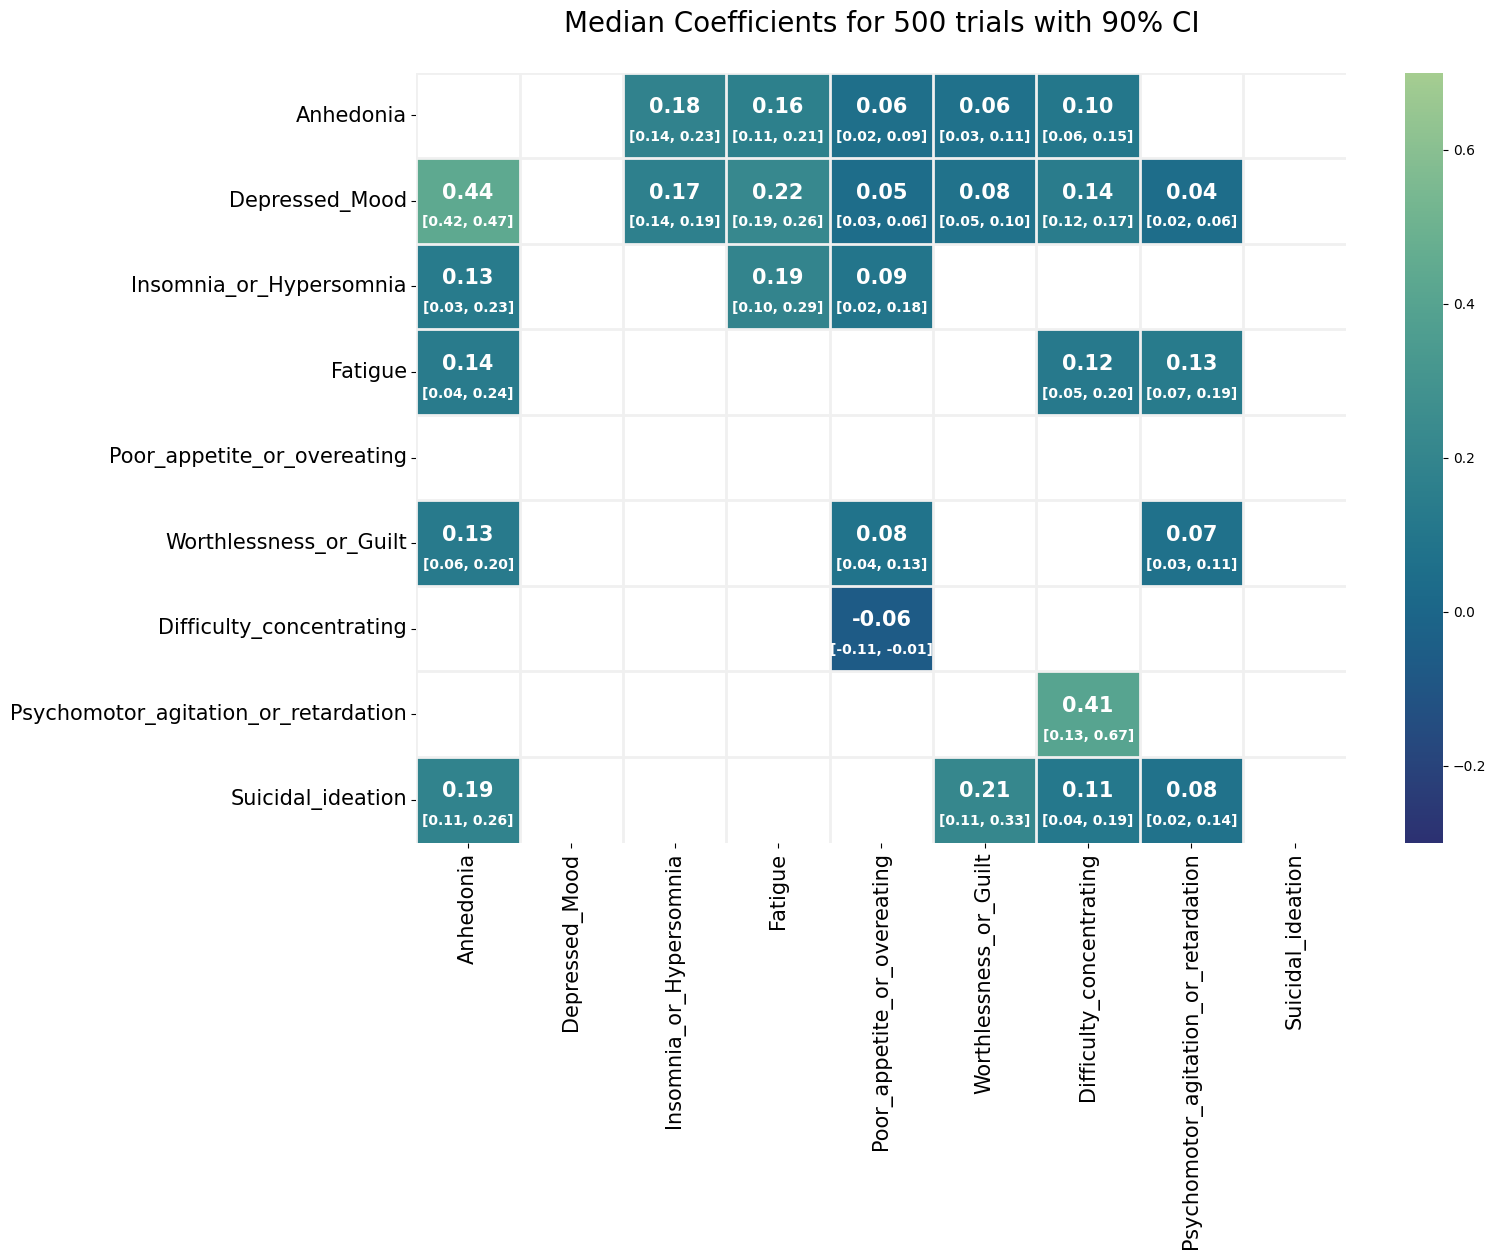

In [57]:
# multivariate_coef2_avg
fig, ax = plt.subplots(figsize=(15, 10))
mask = np.zeros_like(multivariate_coef2_med)
for idx in range(mask.shape[0]):
    for jdx in range(mask.shape[1]):
        # if (idx != jdx) and np.abs(multivariate_coef2_med.iloc[idx, jdx]) <= 0.1:
        if (idx == jdx) or (multivariate_coef2_ci.iloc[idx, jdx][0] <= 0 and multivariate_coef2_ci.iloc[idx, jdx][1] >= 0):
            mask[idx, jdx] = True

mask = mask.astype(bool)             
sns.heatmap(multivariate_coef2_med, annot=False, cmap='crest_r', fmt='', vmin=-0.3, vmax=0.7, mask=mask)

for i, col_i in enumerate(symptoms_columns):
    for j, col_j in enumerate(symptoms_columns):
        if mask[i, j] == False:
            corr_text = "{:0.2f}".format(multivariate_coef2_med.loc[col_i, col_j])
            # conf_bounds = str(multivariate_coef2_std.loc[col_i, col_j])
            conf_bounds = "[{:0.2f}, {:0.2f}]".format(multivariate_coef2_ci.loc[col_i, col_j][0], multivariate_coef2_ci.loc[col_i, col_j][1])
            # conf_bounds = str([multivariate_coef2_ci.loc[col_i, col_j][0].round(2), multivariate_coef2_ci.loc[col_i, col_j][1].round(2)])
              
            ax.text(j + 0.5, i + 0.4, corr_text, ha='center', va='center',
                    fontsize=15, fontweight='bold', color='white')
            ax.text(j + 0.5, i + 0.75, conf_bounds, ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')

ax.set_xticklabels(symptoms_columns, fontsize=15)
ax.set_yticklabels(symptoms_columns, fontsize=15)     

for i in range(9):
    ax.axhline(i, color='#f0f0f0', lw=2)
    ax.axvline(i, color='#f0f0f0', lw=2)

# ax.set_title('Median Coefficients for 500 trials with 90% CI\n(Constrainted)', fontsize=20)
ax.set_title('Median Coefficients for 500 trials with 90% CI\n', fontsize=20)

In [58]:
symptoms_to_sankey = {"Anhedonia": "Anhedonia", "Depressed_Mood": "Depressed", 
                      "Insomnia_or_Hypersomnia": "Sleep", "Fatigue": "Fatigue",
                      "Poor_appetite_or_overeating": "Appetite", "Worthlessness_or_Guilt": "Worthlessness",
                      "Difficulty_concentrating": "Concentration", "Psychomotor_agitation_or_retardation": "Psychomotor",
                      "Suicidal_ideation": "Suicidal"}

for idx, symptom_exp in enumerate(multivariate_coef2_med.index):
    for jdx, symptom_imp in enumerate(multivariate_coef2_med.columns):
        if mask[idx, jdx]: continue
        print ("{}_exp [{:0.2f}] {}_imp".format(symptoms_to_sankey[symptom_exp], multivariate_coef2_med.iloc[idx, jdx].round(2), symptoms_to_sankey[symptom_imp]))
    print ()

Anhedonia_exp [0.18] Sleep_imp
Anhedonia_exp [0.16] Fatigue_imp
Anhedonia_exp [0.06] Appetite_imp
Anhedonia_exp [0.06] Worthlessness_imp
Anhedonia_exp [0.10] Concentration_imp

Depressed_exp [0.44] Anhedonia_imp
Depressed_exp [0.17] Sleep_imp
Depressed_exp [0.22] Fatigue_imp
Depressed_exp [0.05] Appetite_imp
Depressed_exp [0.08] Worthlessness_imp
Depressed_exp [0.14] Concentration_imp
Depressed_exp [0.04] Psychomotor_imp

Sleep_exp [0.13] Anhedonia_imp
Sleep_exp [0.19] Fatigue_imp
Sleep_exp [0.09] Appetite_imp

Fatigue_exp [0.14] Anhedonia_imp
Fatigue_exp [0.12] Concentration_imp
Fatigue_exp [0.13] Psychomotor_imp


Worthlessness_exp [0.13] Anhedonia_imp
Worthlessness_exp [0.08] Appetite_imp
Worthlessness_exp [0.07] Psychomotor_imp

Concentration_exp [-0.06] Appetite_imp

Psychomotor_exp [0.41] Concentration_imp

Suicidal_exp [0.19] Anhedonia_imp
Suicidal_exp [0.21] Worthlessness_imp
Suicidal_exp [0.11] Concentration_imp
Suicidal_exp [0.08] Psychomotor_imp

